# Phase 2 — Exploratory Data Analysis
**Munich Bike Counter Network · Munich Cycling Count Stations (Radverkehrszählstellen München) · 2008–2026**

This notebook drives every modeling decision in the thesis.  
Objective: characterise the data well enough to select stations, specify seasonality periods, choose regressors, flag gotchas, and define a defensible train/val/test split.

| Section | Question answered |
|---------|-------------------|
| 1 | Is the data good enough to model? Which stations are reliable? |
| 2 | What long-term trends and structural breaks exist? |
| 3 | What seasonal periods must the models capture? |
| 4 | Which weather variables add predictive signal? |
| 5 | Do stations differ enough to warrant separate models? |
| 6 | What anomalies and shocks will stress-test the models? |
| 7 | Is the proposed train/val/test split well-calibrated? |
| 8 | What does all of this imply for model architecture? |

## Setup

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

# ── publication style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.size'         : 11,
    'axes.labelsize'    : 12,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'legend.frameon'    : False,
    'legend.fontsize'   : 10,
})
sns.set_theme(style='whitegrid', palette='colorblind')

# ── paths ────────────────────────────────────────────────────────────────────
FIGURES = Path('../results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# ── notebook prefix: all figures saved as nb02_<name>.png ────────────────────
NB = 'nb02'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

# ── consistent station palette (used in every plot) ──────────────────────────
COLORS = {
    'Arnulf'    : '#1f77b4',
    'Erhardt'   : '#ff7f0e',
    'Hirsch'    : '#2ca02c',
    'Kreuther'  : '#9467bd',
    'Margareten': '#d62728',
    'Olympia'   : '#17becf',
}
STATIONS = list(COLORS)
MONTHS   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
WEEKDAYS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# ── split boundaries ─────────────────────────────────────────────────────────
TRAIN_END  = pd.Timestamp('2022-12-31')
VAL_START  = pd.Timestamp('2023-01-01')
VAL_END    = pd.Timestamp('2023-12-31')
TEST_START = pd.Timestamp('2024-01-01')
TEST_END   = pd.Timestamp('2026-04-30')

print('Setup complete. Figures will be saved to:', FIGURES.resolve())

Setup complete. Figures will be saved to: /Users/sousadaniela/time-series-rad/results/figures


In [2]:
from data_loader import load_master_data

df = load_master_data('../data/processed/master_bike_data.csv')

# ── temporal feature engineering ─────────────────────────────────────────────
df['year']     = df['date'].dt.year
df['month']    = df['date'].dt.month
df['weekday']  = df['date'].dt.dayofweek          # 0=Mon … 6=Sun
df['doy']      = df['date'].dt.dayofyear
df['is_wknd']  = df['weekday'] >= 5
df['month_nm'] = pd.Categorical(df['date'].dt.strftime('%b'), MONTHS, ordered=True)
df['wday_nm']  = pd.Categorical(df['date'].dt.strftime('%a'), WEEKDAYS, ordered=True)

# ── pre-build clean Hirsch series for STL/ACF (cleanest continuous station) ──
hirsch_raw   = df[df['station']=='Hirsch'].set_index('date')['total'].sort_index()
hirsch_range = pd.date_range(hirsch_raw.index.min(), hirsch_raw.index.max(), freq='D')
hirsch_clean = hirsch_raw.reindex(hirsch_range).interpolate(method='linear', limit=14)
# Trim to 2010 (2008 is all NaN, 2009 only 25 days)
hirsch_clean = hirsch_clean['2010-01-01':]

print(f'Dataset: {len(df):,} rows  |  {df["station"].nunique()} stations  |  '
      f'{df["date"].min().date()} → {df["date"].max().date()}')
print(f'Hirsch clean series: {len(hirsch_clean):,} days (2010–2026, linear-interpolated gaps ≤14d)')
df.groupby('station', observed=True)[['total','min_temp','max_temp']].describe().round(1)

Dataset: 35,221 rows  |  6 stations  |  2008-06-01 → 2026-04-30
Hirsch clean series: 5,964 days (2010–2026, linear-interpolated gaps ≤14d)


total                                                          \
             count    mean     std    min     25%     50%     75%      max   
station                                                                      
Arnulf      6100.0  1104.1   721.2    0.0   564.8  1000.5  1489.0   4514.0   
Erhardt     5312.0  3852.5  2247.5  102.0  2066.0  3499.0  5434.0  12283.0   
Hirsch      5989.0  1032.6   771.3    0.0   417.0   847.0  1500.0   3745.0   
Kreuther    5411.0   396.9   318.4    0.0   157.5   305.0   577.0   1787.0   
Margareten  4435.0  2703.7  1446.2    0.0  1595.5  2611.0  3717.5   7652.0   
Olympia     6039.0  1737.8  1143.7    0.0   905.0  1517.0  2390.0  15009.0   

           min_temp       ...             max_temp                             \
              count mean  ...   75%   max    count  mean  std  min  25%   50%   
station                   ...                                                   
Arnulf       6512.0  5.7  ...  11.2  21.5   6512.0  14.9  9.1 -9.9  7.7  15.1   
Erhardt      5336.0  5.9  ...  11.5  21.5   5336.0  15.2  9.0 -9.9  8.0  15.2   
Hirsch       6543.0  5.7  ...  11.3  21.5   6543.0  15.0  9.1 -9.9  7.7  15.2   
Kreuther     5720.0  5.4  ...  11.0  21.5   5720.0  14.6  9.1 -9.9  7.4  14.8   
Margareten   4567.0  5.9  ...  11.4  21.5   4567.0  15.2  9.0 -9.9  8.0  15.4   
Olympia      6543.0  5.7  ...  11.3  21.5   6543.0  15.0  9.1 -9.9  7.7  15.2   

                        
             75%   max  
station                 
Arnulf      22.1  36.9  
Erhardt     22.4  36.9  
Hirsch      22.2  36.9  
Kreuther    21.9  36.9  
Margareten  22.5  36.9  
Olympia     22.2  36.9  

[6 rows x 24 columns]

---
## 1 · Data Quality Assessment

**Question:** Which stations have enough reliable data to model, and what gaps will we need to handle in training?

In [3]:
# ── valid days per station-year ───────────────────────────────────────────────
years = list(range(2008, 2027))
records = []
for st in STATIONS:
    for yr in years:
        sub = df[(df['station'] == st) & (df['year'] == yr)]
        records.append({
            'station': st, 'year': yr,
            'n_valid': int(sub['total'].notna().sum()),
            'n_rows' : len(sub),
        })

avail = pd.DataFrame(records)
# Null out years where station had zero rows (not active)
avail.loc[avail['n_rows'] == 0, 'n_valid'] = np.nan

pivot_valid = avail.pivot(index='year', columns='station', values='n_valid')

# Show table
pivot_valid.astype('Int64').style.background_gradient(cmap='YlOrRd', axis=None, vmin=0, vmax=365)

station,Arnulf,Erhardt,Hirsch,Kreuther,Margareten,Olympia
year,,,,,,
2008,214,,0,195,,0
2009,347,,25,320,,155
2010,337,,365,365,,365
2011,365,160,365,365,177,365
2012,366,366,366,366,366,366
2013,365,365,365,134,358,365
2014,365,365,365,365,365,365
2015,349,365,365,365,365,365
2016,366,366,366,366,366,364


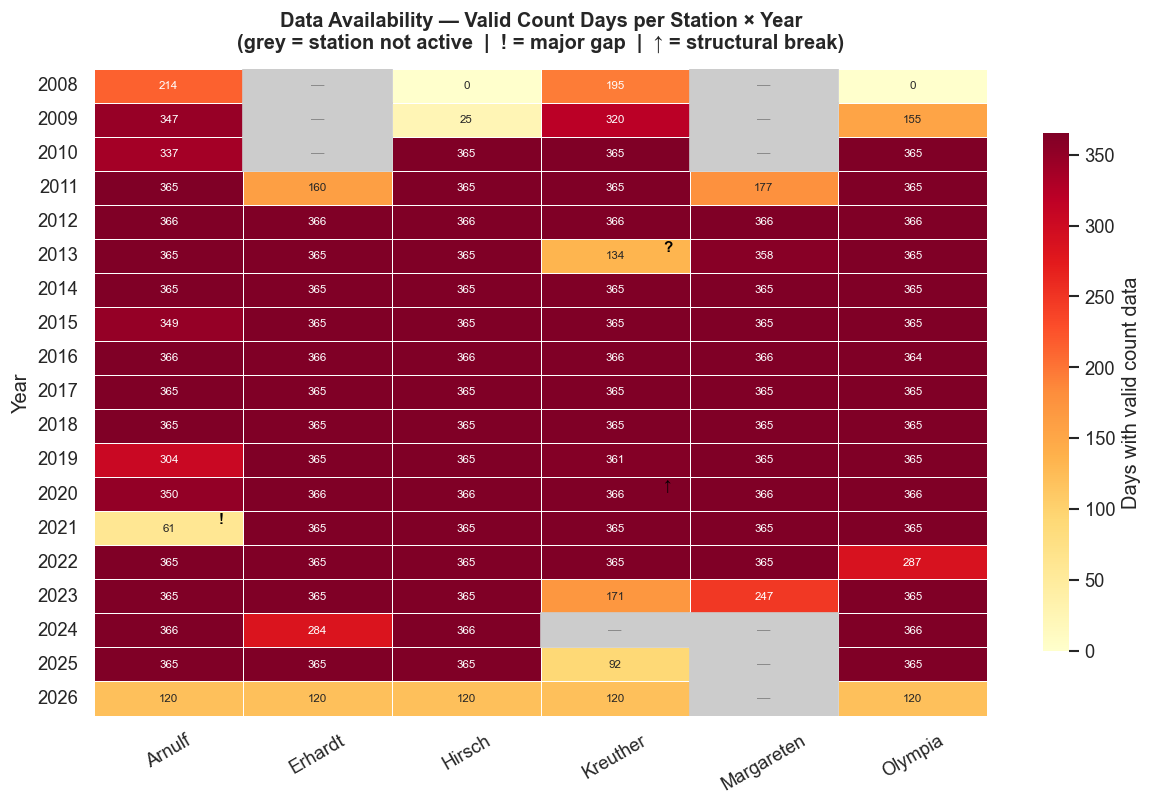

  saved → results/figures/nb02_fig_01_data_availability_heatmap.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

# Grey mask for inactive station-years
inactive_mask = pivot_valid.isna()

sns.heatmap(
    pivot_valid,
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=365,
    linewidths=0.4,
    linecolor='white',
    mask=inactive_mask,
    annot=True, fmt='.0f', annot_kws={'size': 7},
    cbar_kws={'label': 'Days with valid count data', 'shrink': 0.8},
)

# Overlay grey rectangles for inactive station-years
for yi, yr in enumerate(pivot_valid.index):
    for xi, st in enumerate(pivot_valid.columns):
        if inactive_mask.loc[yr, st]:
            ax.add_patch(plt.Rectangle((xi, yi), 1, 1, fill=True,
                                       color='#cccccc', zorder=2))
            ax.text(xi + 0.5, yi + 0.5, '—', ha='center', va='center',
                    fontsize=8, color='#888888', zorder=3)

# Annotate critical anomalies
for yr, st, note in [
    (2021, 'Arnulf',   '!'),
    (2013, 'Kreuther', '?'),
    (2020, 'Kreuther', '↑'),
]:
    xi = list(pivot_valid.columns).index(st)
    yi = list(pivot_valid.index).index(yr)
    ax.text(xi + 0.85, yi + 0.25, note, ha='center', va='center',
            fontsize=9, color='black', fontweight='bold', zorder=4)

ax.set_title('Data Availability — Valid Count Days per Station × Year\n'
             '(grey = station not active  |  ! = major gap  |  ↑ = structural break)',
             pad=12)
ax.set_xlabel('')
ax.set_ylabel('Year')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

savefig('fig_01_data_availability_heatmap')

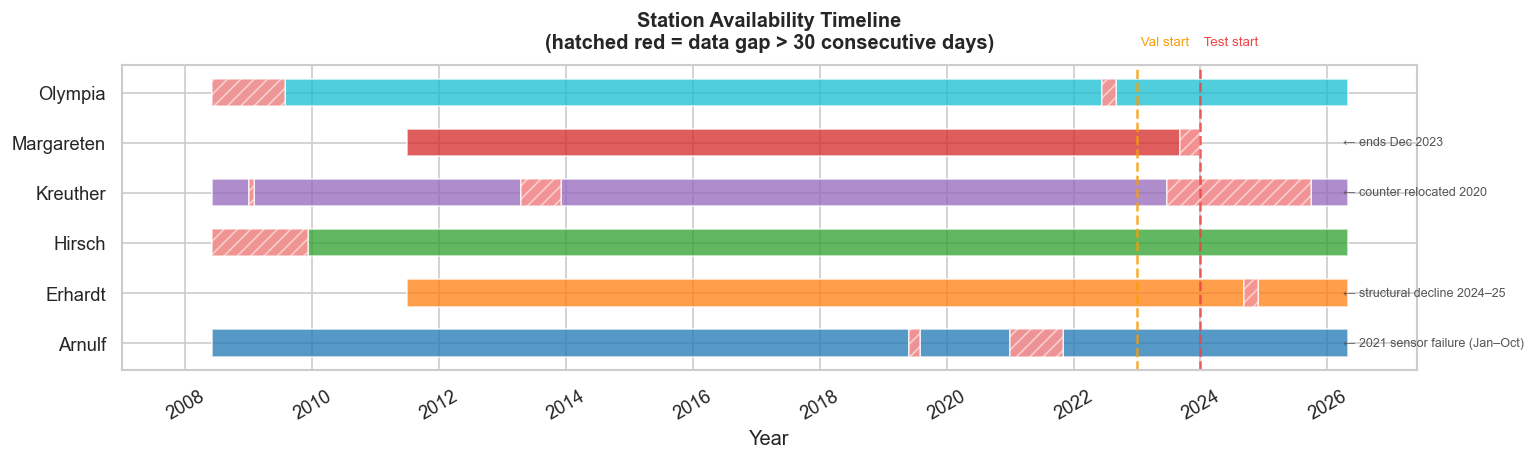

  saved → results/figures/nb02_fig_02_station_timeline.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))

for i, st in enumerate(STATIONS):
    st_data = df[df['station'] == st]
    first, last = st_data['date'].min(), st_data['date'].max()

    # Main active bar
    ax.barh(i, left=first, width=(last - first),
            height=0.55, color=COLORS[st], alpha=0.75)

    # Overlay gaps > 30 consecutive days in red
    full_idx = pd.date_range(first, last, freq='D')
    daily = st_data.set_index('date')['total'].reindex(full_idx)
    is_gap  = daily.isna()
    grp_ids = (is_gap != is_gap.shift()).cumsum()
    for _, grp in daily.groupby(grp_ids):
        if grp.isna().all() and len(grp) > 30:
            ax.barh(i, left=grp.index[0], width=(grp.index[-1] - grp.index[0]),
                    height=0.55, color='white', alpha=0.9)
            ax.barh(i, left=grp.index[0], width=(grp.index[-1] - grp.index[0]),
                    height=0.55, color='#ef4444', alpha=0.55, hatch='///')

ax.set_yticks(range(len(STATIONS)))
ax.set_yticklabels(STATIONS)
ax.set_xlabel('Year')
ax.set_title('Station Availability Timeline\n(hatched red = data gap > 30 consecutive days)', pad=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=30)

# Mark train/val/test boundaries
for date, label, color in [
    (VAL_START,  'Val start',  '#f59e0b'),
    (TEST_START, 'Test start', '#ef4444'),
]:
    ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.85)
    ax.text(date, len(STATIONS) - 0.05, f' {label}', color=color, fontsize=8)

# Station notes
notes = {
    'Arnulf'    : '← 2021 sensor failure (Jan–Oct)',
    'Kreuther'  : '← counter relocated 2020',
    'Margareten': '← ends Dec 2023',
    'Erhardt'   : '← structural decline 2024–25',
}
for st, note in notes.items():
    yi = STATIONS.index(st)
    ax.text(pd.Timestamp('2026-04-01'), yi, note, va='center', fontsize=7.5,
            color='#555555')

ax.set_xlim(pd.Timestamp('2007-01-01'), pd.Timestamp('2027-06-01'))
plt.tight_layout()
savefig('fig_02_station_timeline')

### Quality Assessment Findings

**Arnulf — major 2021 gap:** The sensor failed from January through October 2021 — 304 of 365 days have no count data. This gap falls squarely in the training set (2013–2022). Any model trained on Arnulf must either impute this period or restrict training to 2013–2020 + 2022.

**Kreuther — structural break 2020:** Daily mean jumped from ≈265/day (2015–2019) to ≈671/day (2020–2022) — a 2.5× discontinuity. The most likely explanation is counter relocation or infrastructure change (new cycle lane or bridge). Models trained on pre/post break data together will be confused. **Recommended:** use Kreuther 2020–2025 only, or add a binary break indicator.

**Erhardt — structural decline 2024–2025:** Mean fell from 4,765/day (2023 validation mean) to ~3,950/day over the test period (2024–2026), a −17.1% decline. This structural break lands in the test period, making Erhardt a genuinely challenging (and interesting) forecasting target.

**Margareten — test-set exclusion:** Station ends 2023-12-31 with no 2024/2025 data. Cannot be evaluated on the test set. **Excluded from primary analysis.**

**Hirsch — cleanest station:** Near-complete 2011–2025, only 554 gap-days (mostly small isolated outages), strong steady growth. **Best prototype station for initial model development.**

**Olympia & Arnulf — moderate gaps:** Manageable, scattered gaps of < 30 days, suitable for interpolation.

---
## 2 · Temporal Patterns

**Question:** What trends are present, and are they stable enough to extrapolate?

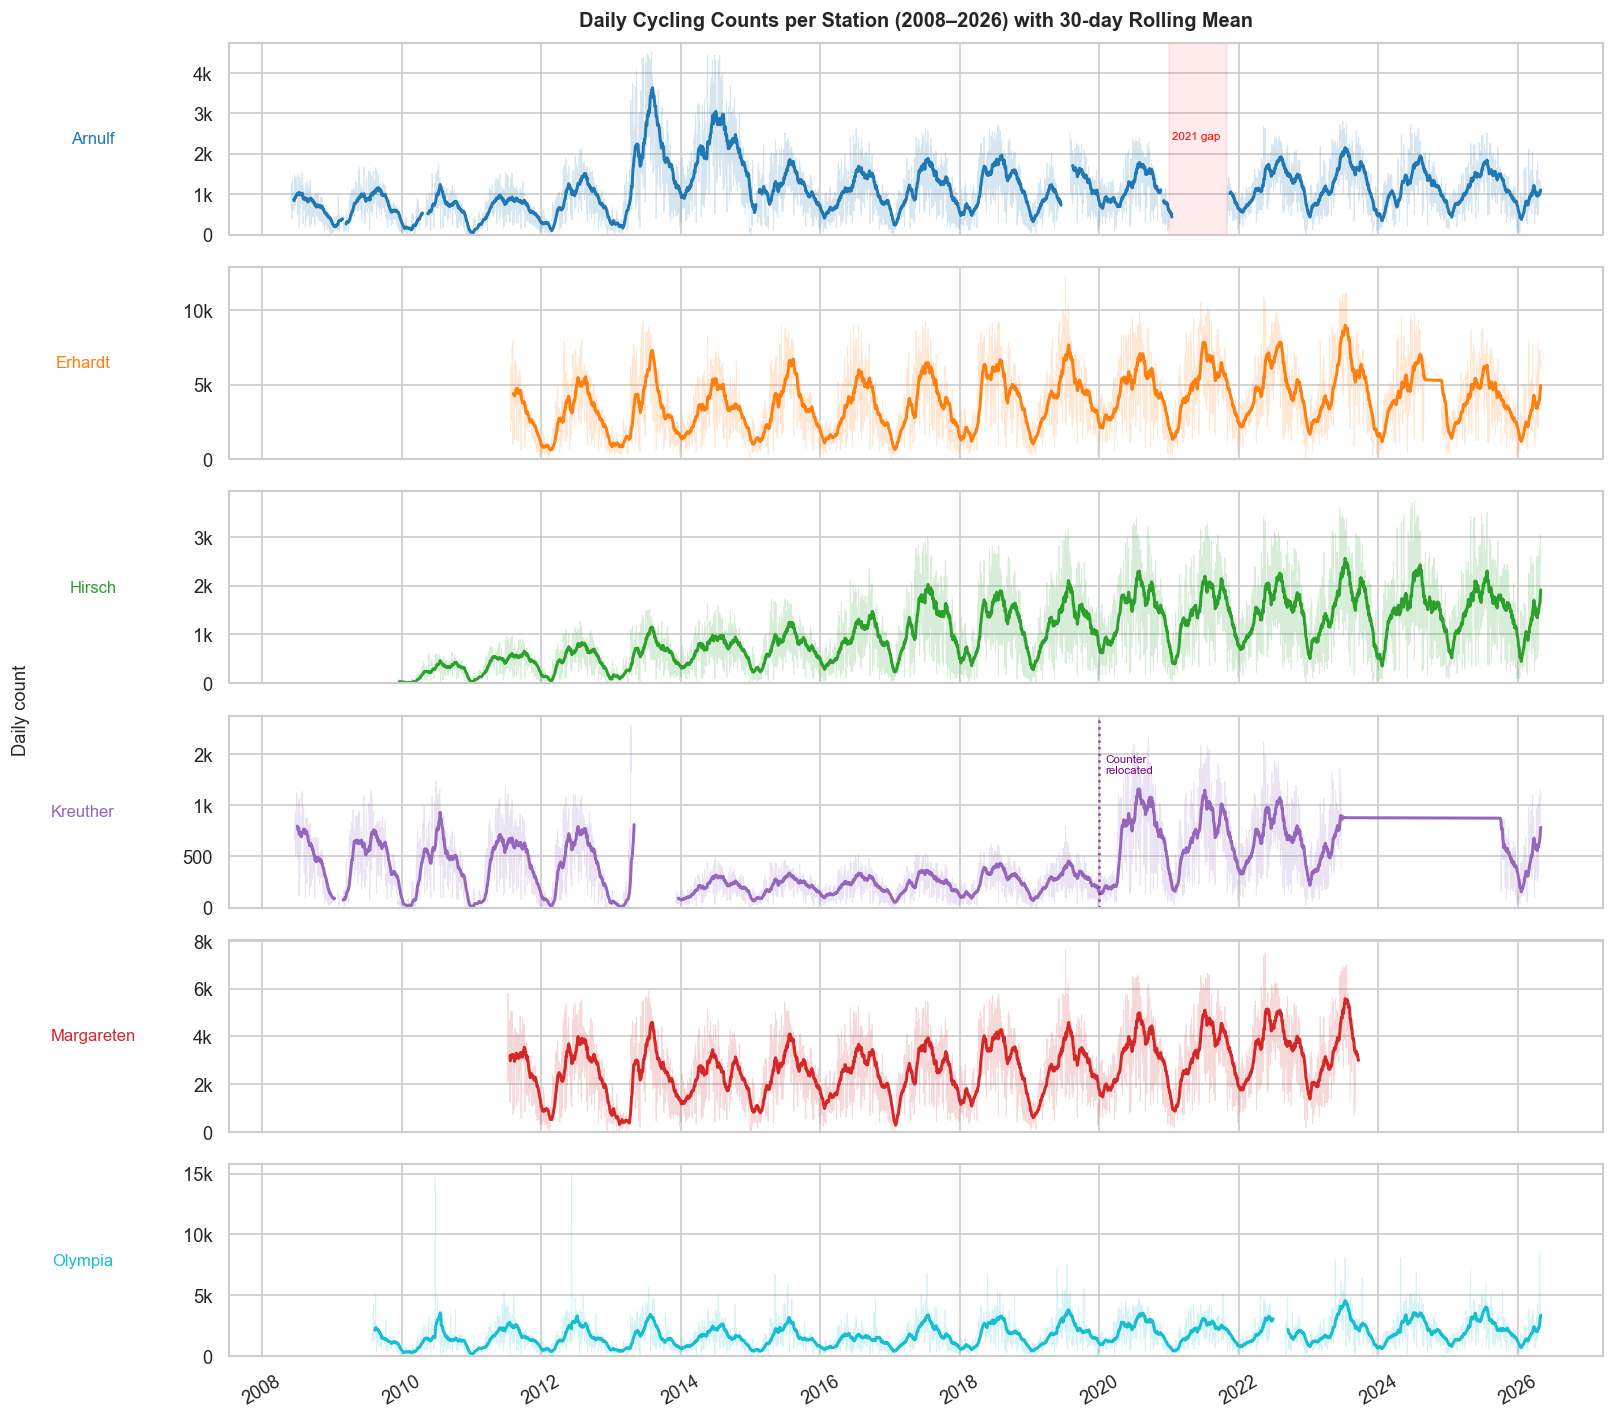

  saved → results/figures/nb02_fig_03_full_timeseries.png


In [6]:
fig, axes = plt.subplots(len(STATIONS), 1, figsize=(14, 12), sharex=True)

for ax, st in zip(axes, STATIONS):
    st_ts = df[df['station'] == st].set_index('date')['total'].sort_index()

    ax.plot(st_ts.index, st_ts.values, color=COLORS[st], alpha=0.18, linewidth=0.5)

    r30 = st_ts.rolling(30, min_periods=15).mean()
    ax.plot(r30.index, r30.values, color=COLORS[st], linewidth=1.8, label='30d rolling mean')

    ax.set_ylabel(st, rotation=0, labelpad=60, va='center', fontsize=10, color=COLORS[st])
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}'))

    if st == 'Kreuther':
        ax.axvline(pd.Timestamp('2020-01-01'), color='purple', linestyle=':', linewidth=1.5, alpha=0.7)
        ax.text(pd.Timestamp('2020-02-01'), ax.get_ylim()[1] * 0.7, 'Counter\nrelocated', fontsize=7, color='purple')

    if st == 'Arnulf':
        ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-11-01'), color='red', alpha=0.08)
        ax.text(pd.Timestamp('2021-01-15'), ax.get_ylim()[1] * 0.5, '2021 gap', fontsize=7, color='red')

axes[0].set_title('Daily Cycling Counts per Station (2008–2026) with 30-day Rolling Mean', pad=10)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=30)
fig.text(0.04, 0.5, 'Daily count', va='center', rotation='vertical', fontsize=11)
plt.tight_layout(rect=[0.05, 0, 1, 1])
savefig('fig_03_full_timeseries')

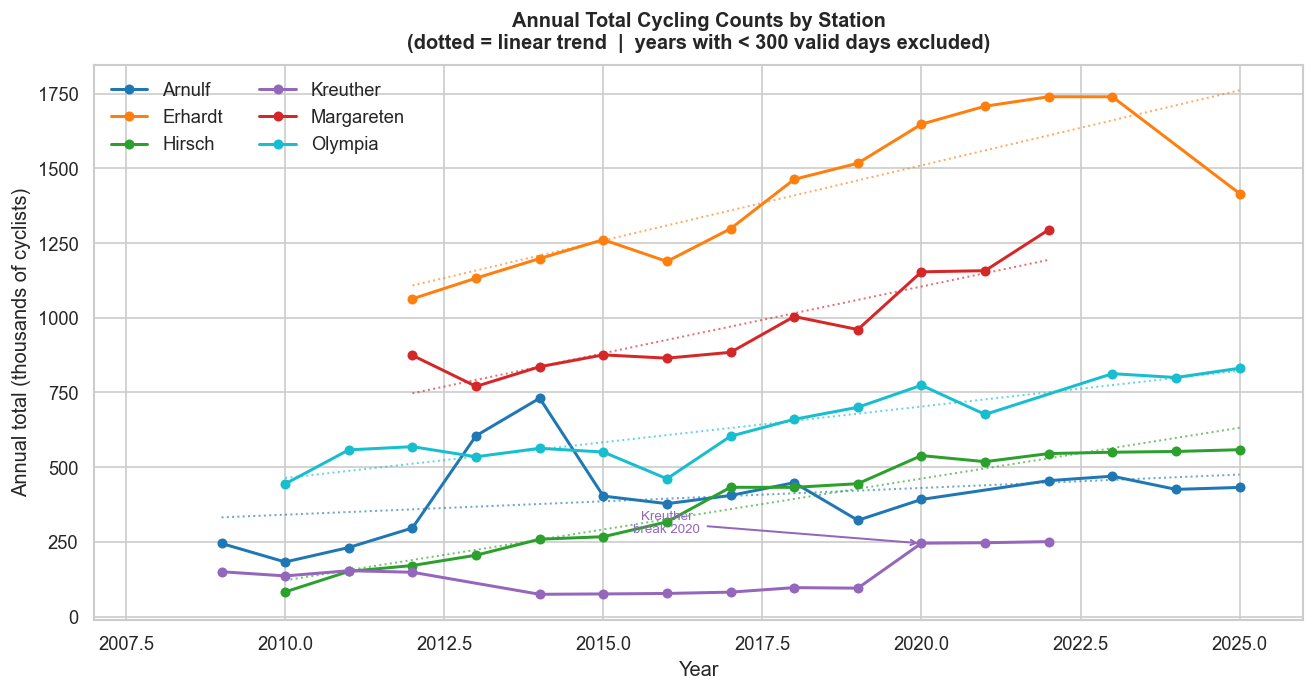

  saved → results/figures/nb02_fig_04_annual_totals_and_trends.png


In [7]:
# ── annual totals: only use station-years with ≥ 300 valid days ──────────────
ann_records = []
for st in STATIONS:
    for yr in range(2008, 2026):
        sub = df[(df['station'] == st) & (df['year'] == yr)]
        nv  = sub['total'].notna().sum()
        if nv >= 300:
            ann_records.append({'station': st, 'year': yr,
                                 'total': sub['total'].sum(),
                                 'n_valid': nv})

ann = pd.DataFrame(ann_records)

fig, ax = plt.subplots(figsize=(13, 6))

for st in STATIONS:
    sub = ann[ann['station'] == st]
    ax.plot(sub['year'], sub['total'] / 1000, color=COLORS[st],
            marker='o', markersize=5, linewidth=1.8, label=st)

    trend_sub = sub.copy()
    if st == 'Kreuther':
        trend_sub = trend_sub[trend_sub['year'] >= 2020]
    if len(trend_sub) >= 5:
        sl, ic, *_ = stats.linregress(trend_sub['year'], trend_sub['total'] / 1000)
        xs = np.array([trend_sub['year'].min(), trend_sub['year'].max()])
        ax.plot(xs, sl * xs + ic, color=COLORS[st], linestyle=':', linewidth=1.2, alpha=0.65)

ax.annotate('Kreuther\nbreak 2020', xy=(2020, 245), xytext=(2016, 280),
            arrowprops=dict(arrowstyle='->', color='#9467bd', lw=1.2),
            fontsize=8, color='#9467bd', ha='center')

ax.set_title('Annual Total Cycling Counts by Station\n(dotted = linear trend  |  years with < 300 valid days excluded)', pad=10)
ax.set_xlabel('Year')
ax.set_ylabel('Annual total (thousands of cyclists)')
ax.legend(ncol=2)
ax.set_xlim(2007, 2026)

savefig('fig_04_annual_totals_and_trends')

Variance decomposition — Hirsch 2010–2025:
  Seasonal : 35.6%
  Trend    : 38.1%
  Residual : 45.8%


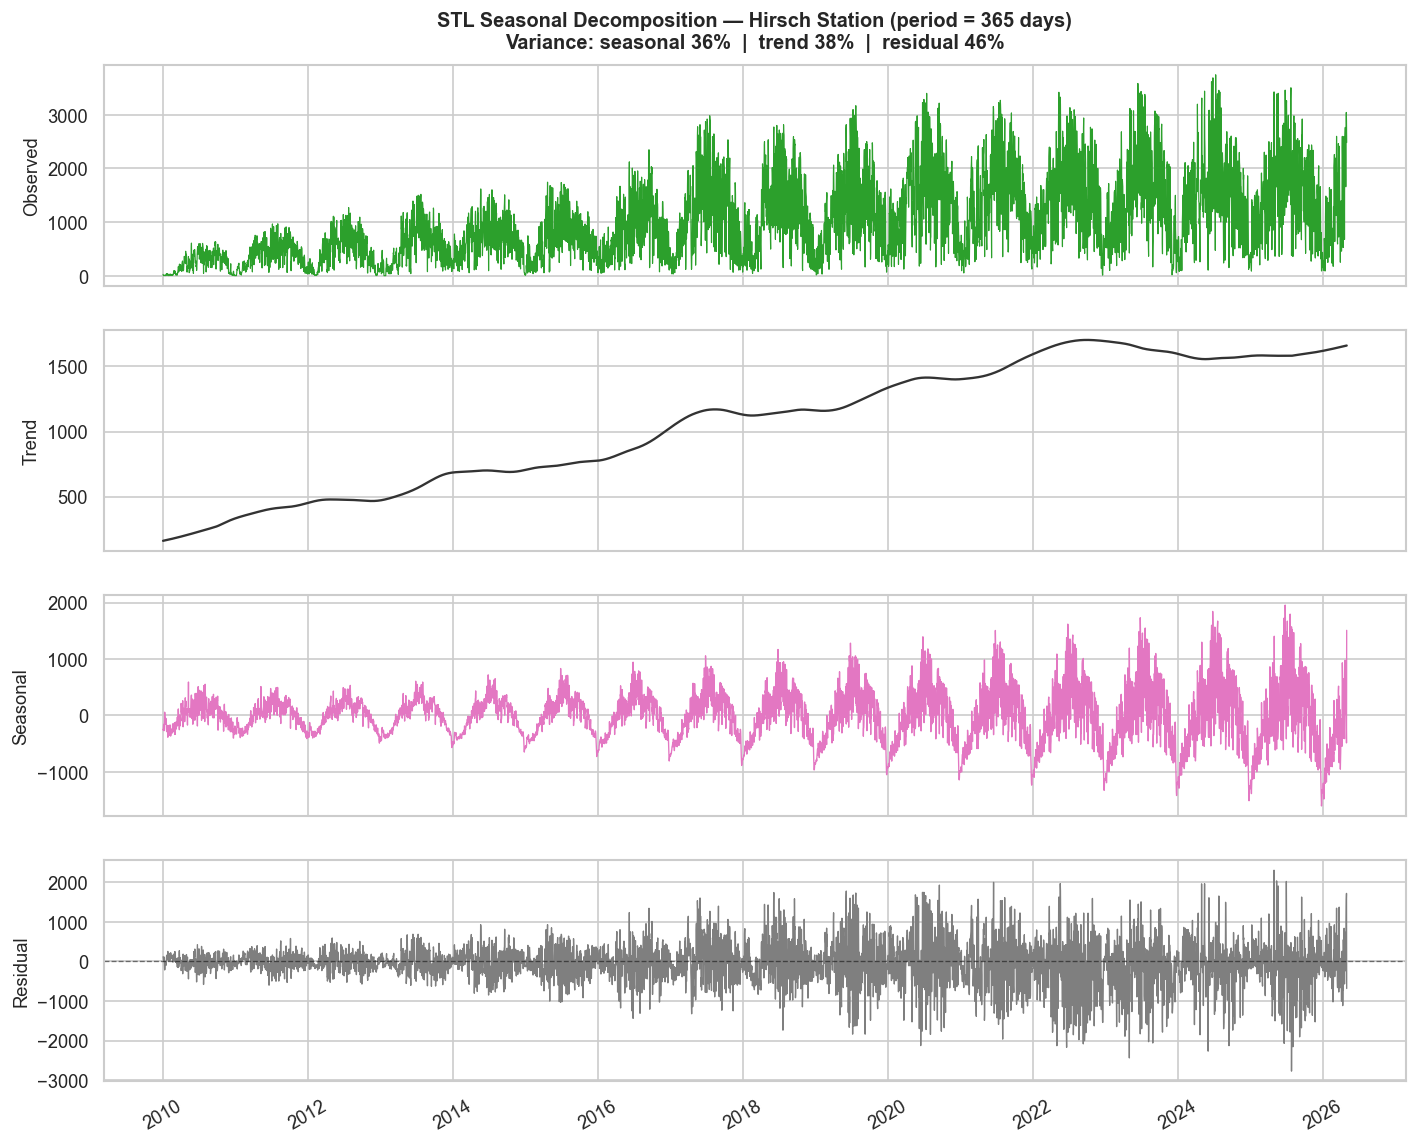

  saved → results/figures/nb02_fig_05_stl_decomposition.png


In [8]:
# ── STL decomposition on Hirsch 2010–2025 (period = 365) ─────────────────────
# Using Hirsch: cleanest station, near-complete data, steady growth
stl_series = hirsch_clean['2010-01-01':'2026-04-30'].dropna()

stl = STL(stl_series, period=365, robust=True, seasonal=365)
res = stl.fit()

total_var    = np.var(stl_series)
seasonal_pct = np.var(res.seasonal) / total_var * 100
trend_pct    = np.var(res.trend.dropna()) / total_var * 100
resid_pct    = np.var(res.resid.dropna()) / total_var * 100

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

panels = [
    ('Observed',  stl_series,   COLORS['Hirsch'],  0.7),
    ('Trend',     res.trend,    '#333333',          1.4),
    ('Seasonal',  res.seasonal, '#e377c2',          0.8),
    ('Residual',  res.resid,    '#7f7f7f',          0.8),
]

for ax, (name, data, color, lw) in zip(axes, panels):
    ax.plot(data.index, data.values, color=color, linewidth=lw)
    if name == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel(name, fontsize=11)

axes[0].set_title(
    f'STL Seasonal Decomposition — Hirsch Station (period = 365 days)\n'
    f'Variance: seasonal {seasonal_pct:.0f}%  |  trend {trend_pct:.0f}%  |  residual {resid_pct:.0f}%',
    pad=10
)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=30)

print(f'Variance decomposition — Hirsch 2010–2025:')
print(f'  Seasonal : {seasonal_pct:.1f}%')
print(f'  Trend    : {trend_pct:.1f}%')
print(f'  Residual : {resid_pct:.1f}%')

savefig('fig_05_stl_decomposition')

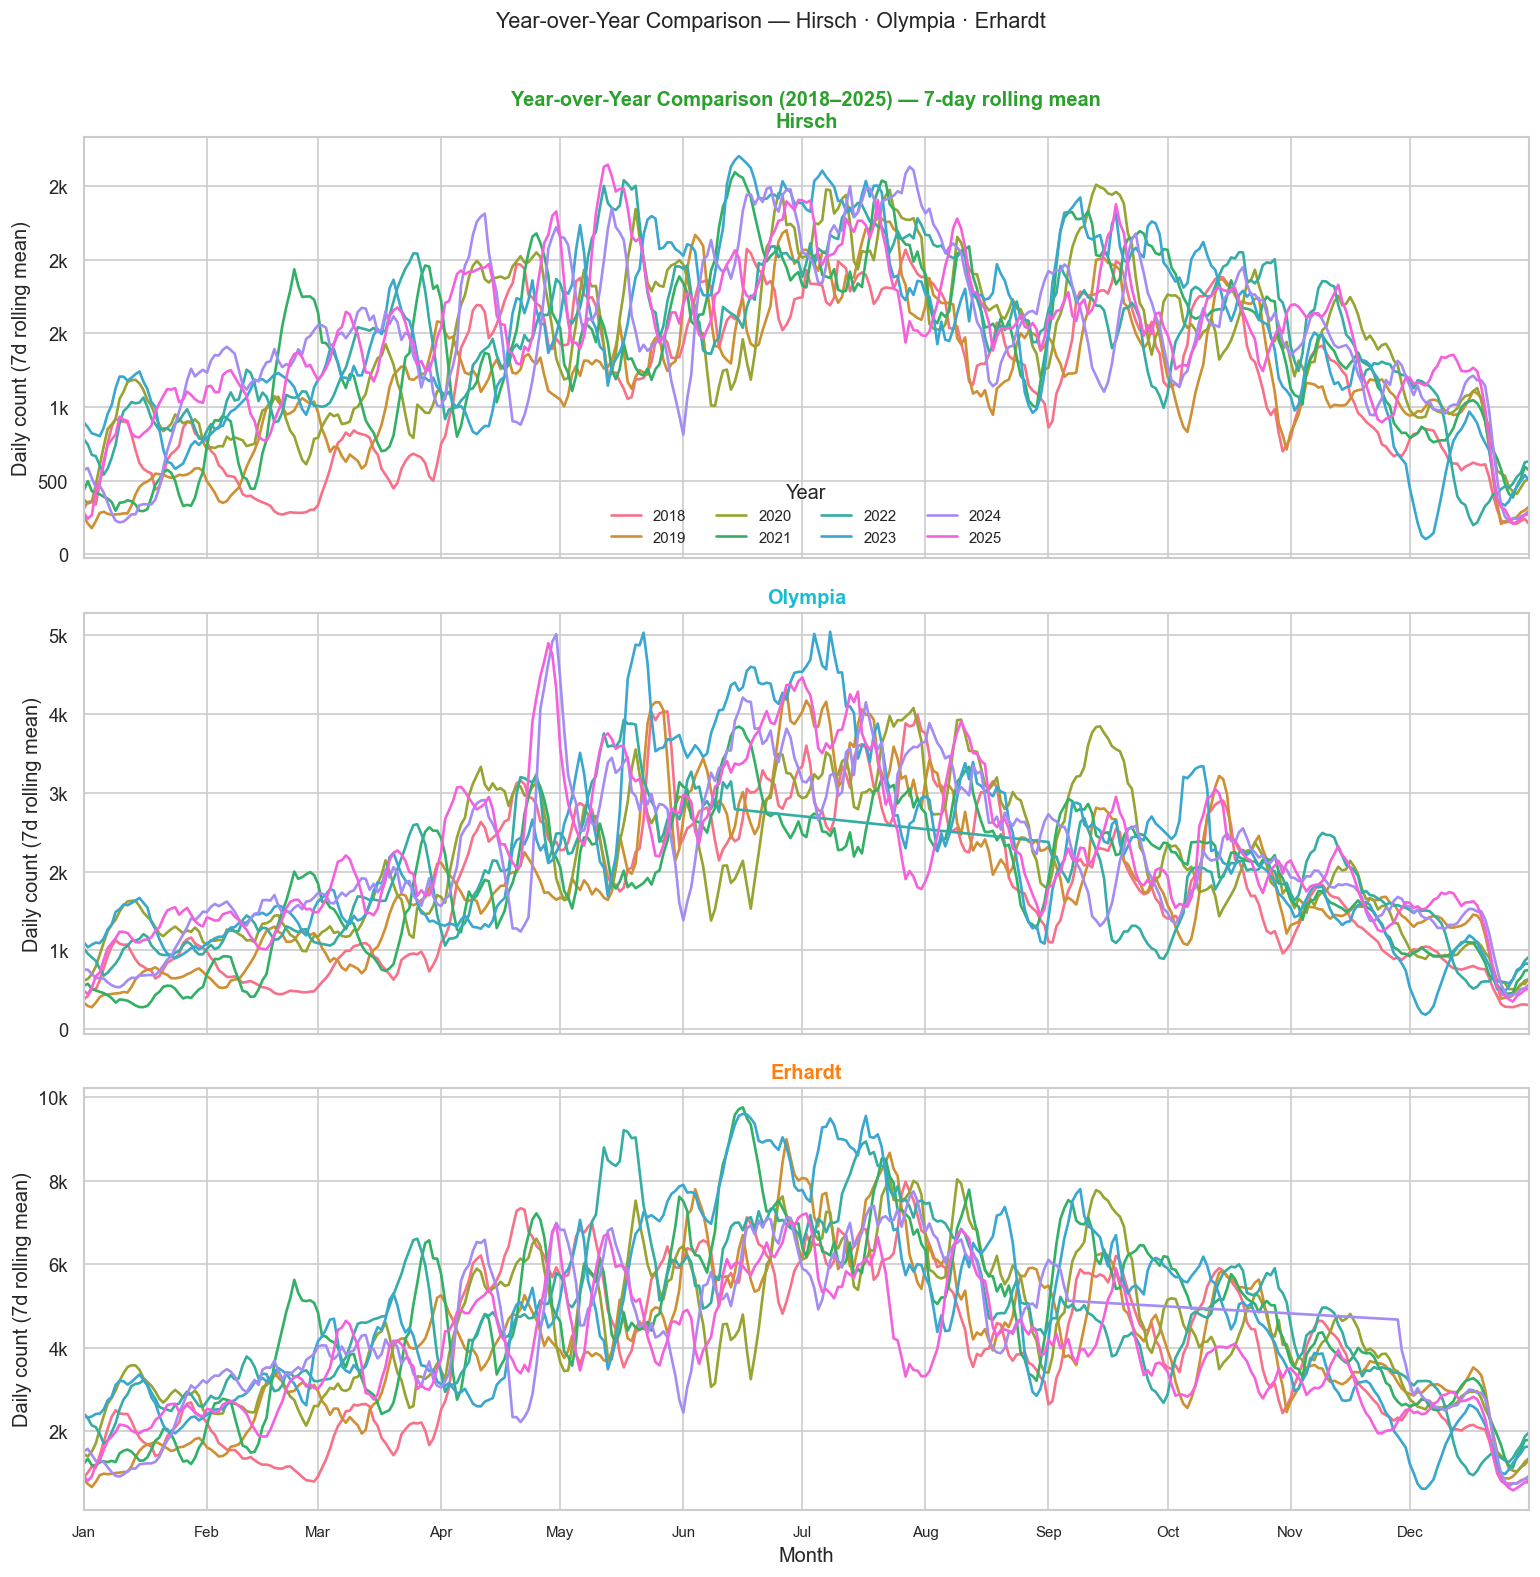

  saved → results/figures/nb02_fig_06_yoy_comparison.png


In [9]:
# ── year-over-year comparison 2018–2025: Hirsch, Olympia, Erhardt ────────────
PRIMARY = ['Hirsch', 'Olympia', 'Erhardt']
years_yoy   = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
palette_yoy = sns.color_palette('husl', len(years_yoy))

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

for ax, st in zip(axes, PRIMARY):
    for yr, col in zip(years_yoy, palette_yoy):
        sub = df[(df['station'] == st) & (df['year'] == yr) &
                 df['total'].notna()].sort_values('doy')
        if len(sub) < 100:
            continue
        r7 = sub.set_index('doy')['total'].rolling(7, min_periods=3, center=True).mean()
        ax.plot(r7.index, r7.values, color=col, linewidth=1.6,
                label=str(yr) if st == PRIMARY[0] else '_')

    ax.set_title(f'{st}', fontsize=12, fontweight='bold', color=COLORS[st])
    ax.set_ylabel('Daily count (7d rolling mean)')
    ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
    ax.set_xticklabels(MONTHS, fontsize=9)
    ax.set_xlim(1, 365)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}'))

axes[0].legend(ncol=4, fontsize=9, title='Year')
axes[0].set_title('Year-over-Year Comparison (2018–2025) — 7-day rolling mean\nHirsch',
                  fontsize=12, fontweight='bold', color=COLORS['Hirsch'])
axes[-1].set_xlabel('Month')

fig.suptitle('Year-over-Year Comparison — Hirsch · Olympia · Erhardt', fontsize=13, y=1.01)
plt.tight_layout()
savefig('fig_06_yoy_comparison')

### Temporal Pattern Findings

**Growth trajectories are station-specific, not system-wide:**
- Hirsch: +7.8 %/yr (R² = 0.88) — explosive, near-linear growth driven by infrastructure investment along its route
- Erhardt: +5.1 %/yr until 2023, then structural decline (−17.1% test mean vs 2023)
- Olympia: +5.8 %/yr, consistent recreational growth
- Arnulf: Only +2.0 %/yr (R² = 0.22) — the oldest, most established corridor is near saturation
- Kreuther: 20.9 %/yr is a statistical artefact of the 2020 counter relocation, not organic growth

**STL decomposition reveals the seasonal signal is dominant:** On Hirsch, the annual seasonal component explains the majority of variance. The trend is visible but smooth. This justifies including both seasonal components (weekly + annual) in every model.

**The year-over-year overlay (2018–2025) shows Munich cycling recovered quickly post-COVID** — 2021–2025 counts at Hirsch track at or above 2018 and 2019 levels, confirming the widely-observed modal-shift effect (people switched from public transport and kept cycling).

---
## 3 · Seasonality Analysis

**Question:** How many seasonal periods should the models explicitly capture, and how strong are they?

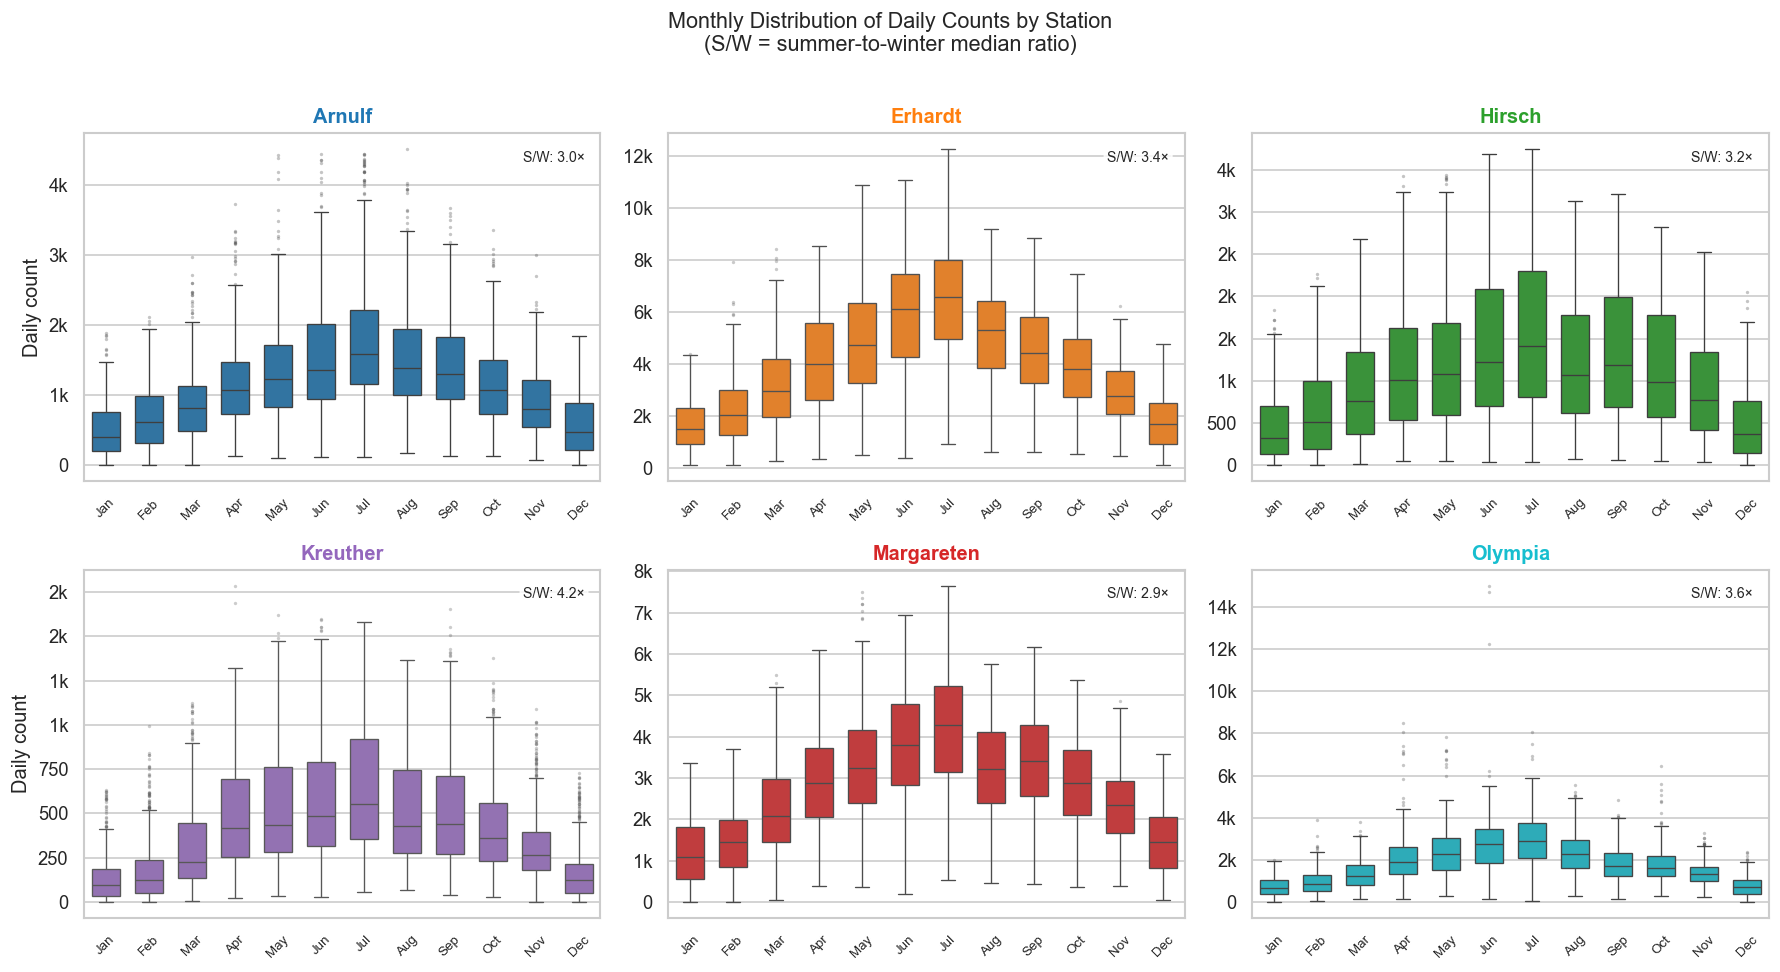

  saved → results/figures/nb02_fig_07_monthly_seasonality.png


In [10]:
# ── monthly distribution: 2×3 grid, one station per panel ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, st in zip(axes.flat, STATIONS):
    sub = df[(df['station'] == st) & df['total'].notna()]
    summer = sub[sub['month'].isin([6, 7, 8])]['total'].median()
    winter = sub[sub['month'].isin([12, 1, 2])]['total'].median()
    ratio  = summer / winter if winter > 0 else np.nan

    sns.boxplot(
        data=sub, x='month_nm', y='total',
        order=MONTHS, color=COLORS[st], ax=ax,
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3},
        width=0.65, linewidth=0.8, whis=1.5,
    )
    ax.set_title(st, fontsize=12, fontweight='bold', color=COLORS[st])
    ax.set_xlabel('')
    ax.set_ylabel('Daily count' if ax in axes[:, 0] else '')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}'))
    ax.text(0.97, 0.95, f'S/W: {ratio:.1f}×',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

fig.suptitle('Monthly Distribution of Daily Counts by Station\n'
             '(S/W = summer-to-winter median ratio)', fontsize=13, y=1.01)
plt.tight_layout()
savefig('fig_07_monthly_seasonality')

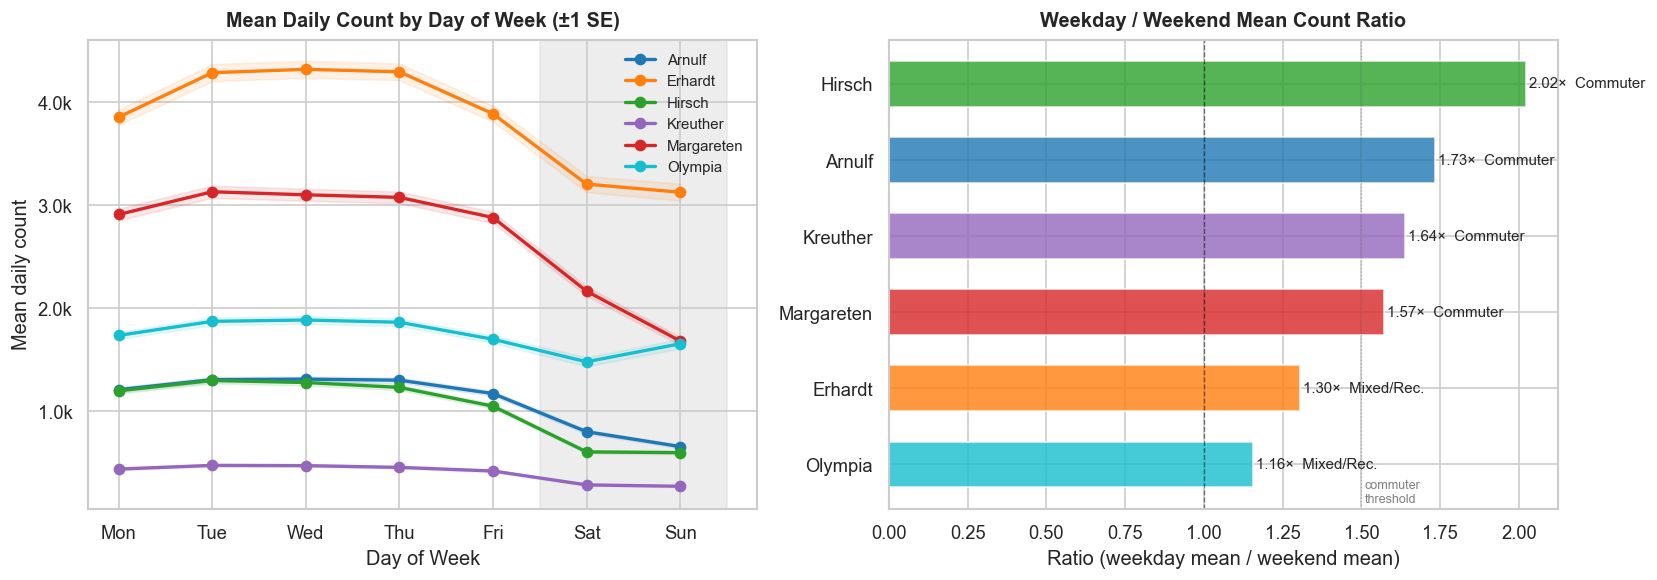

  saved → results/figures/nb02_fig_08_weekday_patterns.png


In [11]:
# ── weekday vs weekend: all stations on one plot ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for st in STATIONS:
    sub = df[(df['station'] == st) & df['total'].notna()]
    grp = (sub.groupby('wday_nm', observed=True)['total']
              .agg(['mean', 'sem'])
              .reindex(WEEKDAYS))
    axes[0].plot(WEEKDAYS, grp['mean'], color=COLORS[st],
                 marker='o', markersize=6, linewidth=2, label=st)
    axes[0].fill_between(WEEKDAYS,
                          grp['mean'] - grp['sem'],
                          grp['mean'] + grp['sem'],
                          color=COLORS[st], alpha=0.1)

axes[0].axvspan(4.5, 6.5, color='lightgrey', alpha=0.4, zorder=0)
axes[0].set_title('Mean Daily Count by Day of Week (±1 SE)', pad=8)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Mean daily count')
axes[0].legend(ncol=1, fontsize=9)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.1f}k' if x >= 1000 else f'{x:.0f}'))

wd_ratios = []
for st in STATIONS:
    sub = df[(df['station'] == st) & df['total'].notna()]
    wd = sub[~sub['is_wknd']]['total'].mean()
    we = sub[sub['is_wknd']]['total'].mean()
    wd_ratios.append({'station': st, 'ratio': wd / we, 'type': 'Commuter' if wd/we > 1.5 else 'Mixed/Rec.'})

ratio_df = pd.DataFrame(wd_ratios).sort_values('ratio', ascending=True)
bar_colors = [COLORS[r] for r in ratio_df['station']]
bars = axes[1].barh(ratio_df['station'], ratio_df['ratio'],
                    color=bar_colors, height=0.6, alpha=0.8)
axes[1].axvline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].axvline(1.5, color='grey',  linewidth=0.8, linestyle=':', alpha=0.5)
axes[1].text(1.51, -0.5, 'commuter\nthreshold', fontsize=7.5, color='grey')
axes[1].set_title('Weekday / Weekend Mean Count Ratio', pad=8)
axes[1].set_xlabel('Ratio (weekday mean / weekend mean)')

for bar, row in zip(bars, ratio_df.itertuples()):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{row.ratio:.2f}×  {row.type}', va='center', fontsize=9)

plt.tight_layout()
savefig('fig_08_weekday_patterns')

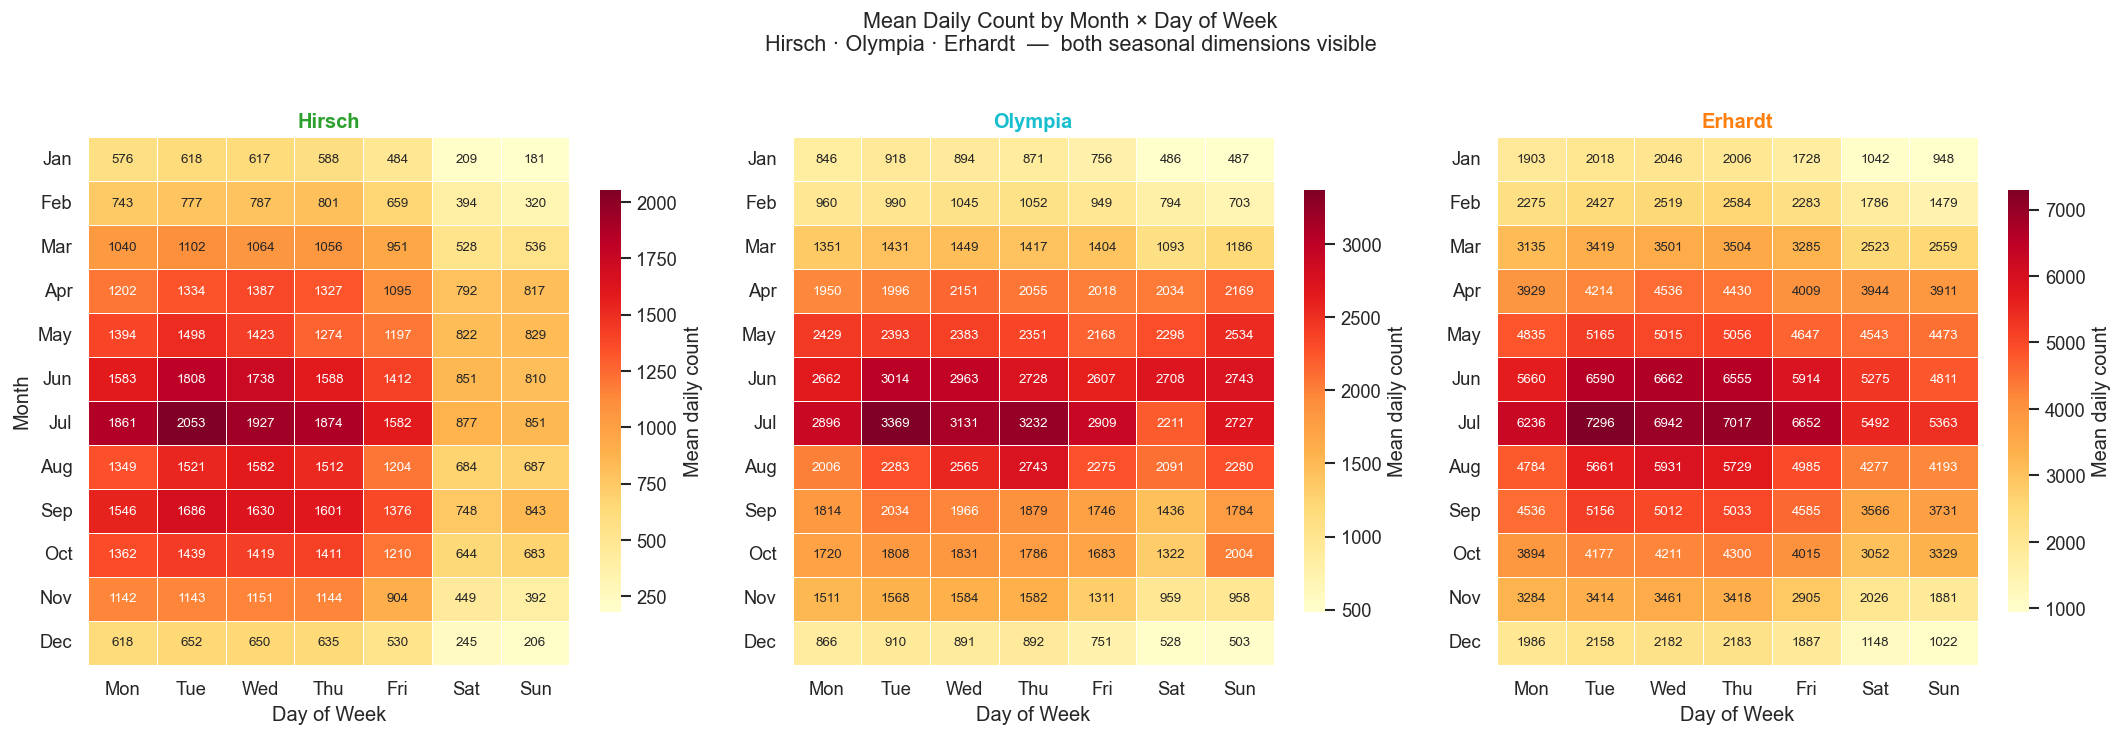

  saved → results/figures/nb02_fig_09_month_weekday_heatmap.png


In [12]:
# ── month × weekday heatmap: Hirsch, Olympia, Erhardt ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, st in zip(axes, PRIMARY):
    sub = df[(df['station'] == st) & df['total'].notna()]
    heat = (
        sub.groupby(['month', 'weekday'], observed=False)['total']
        .mean()
        .unstack('weekday')
    )
    heat.index   = MONTHS
    heat.columns = WEEKDAYS

    sns.heatmap(
        heat, ax=ax,
        cmap='YlOrRd',
        annot=True, fmt='.0f', annot_kws={'size': 8},
        linewidths=0.3,
        cbar_kws={'label': 'Mean daily count', 'shrink': 0.8},
    )
    ax.set_title(st, fontsize=12, fontweight='bold', color=COLORS[st])
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Month' if st == PRIMARY[0] else '')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Mean Daily Count by Month × Day of Week\n'
             'Hirsch · Olympia · Erhardt  —  both seasonal dimensions visible',
             fontsize=13, y=1.02)
plt.tight_layout()
savefig('fig_09_month_weekday_heatmap')

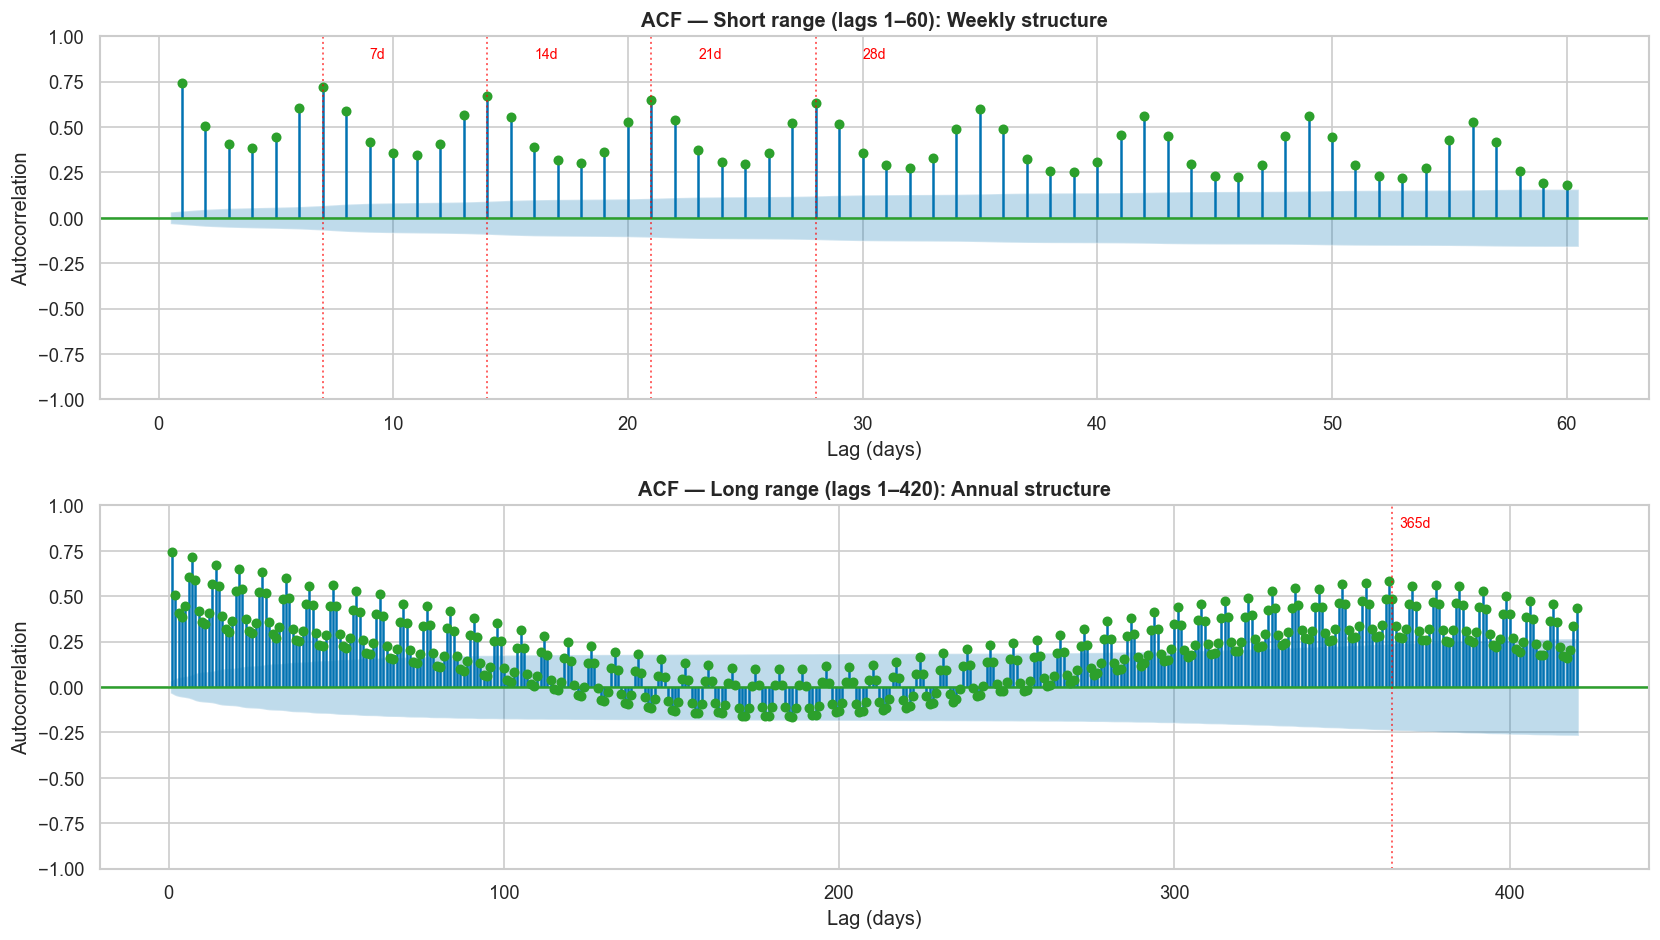

  saved → results/figures/nb02_fig_10_acf.png


In [13]:
# ── ACF: confirm both weekly and annual periodicity ───────────────────────────
acf_series = hirsch_clean['2013-01-01':'2022-12-31'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, nlags, title, key_lags in [
    (axes[0],  60, 'ACF — Short range (lags 1–60): Weekly structure',    [7, 14, 21, 28]),
    (axes[1], 420, 'ACF — Long range (lags 1–420): Annual structure',     [365]),
]:
    plot_acf(acf_series, lags=nlags, ax=ax, zero=False,
             alpha=0.05, color=COLORS['Hirsch'])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Autocorrelation')
    for lag in key_lags:
        ax.axvline(lag, color='red', linestyle=':', alpha=0.6, linewidth=1.2)
        ax.text(lag + 2, ax.get_ylim()[1] * 0.88,
                f'{lag}d', color='red', fontsize=8.5)

plt.tight_layout()
savefig('fig_10_acf')

### Seasonality Findings

**Two seasonal periods are non-negotiable:**
1. **Weekly (s = 7):** Strong weekly pattern visible in both the ACF spike at lag 7 and the weekday/weekend split. Weekday means are 1.3–2.0× higher than weekends depending on station character.
2. **Annual (s = 365):** ACF spike at lag 365 confirms the annual cycle. Summer-to-winter ratios range from 2.9× (Arnulf) to 4.2× (Kreuther) — very large seasonal amplitudes that every model must capture.

**Station character is legible from the weekday/weekend ratio:**
- Hirsch (2.02×) and Arnulf (1.74×): commuter-dominated
- Olympia (1.16×) and Erhardt (1.31×): recreational/mixed — weekend counts are nearly as high as weekday
- This distinction matters for model selection: commuter stations are more predictable (regular schedules) while recreational stations are more weather-sensitive

**The month × weekday heatmap shows a multiplicative interaction** — the weekend dip is proportionally larger in summer. This multiplicative structure suggests log-transformed targets or multiplicative decomposition in Prophet.

---
## 4 · Weather Correlations

**Question:** Which weather variables add genuine predictive signal beyond what the seasonal model already captures?

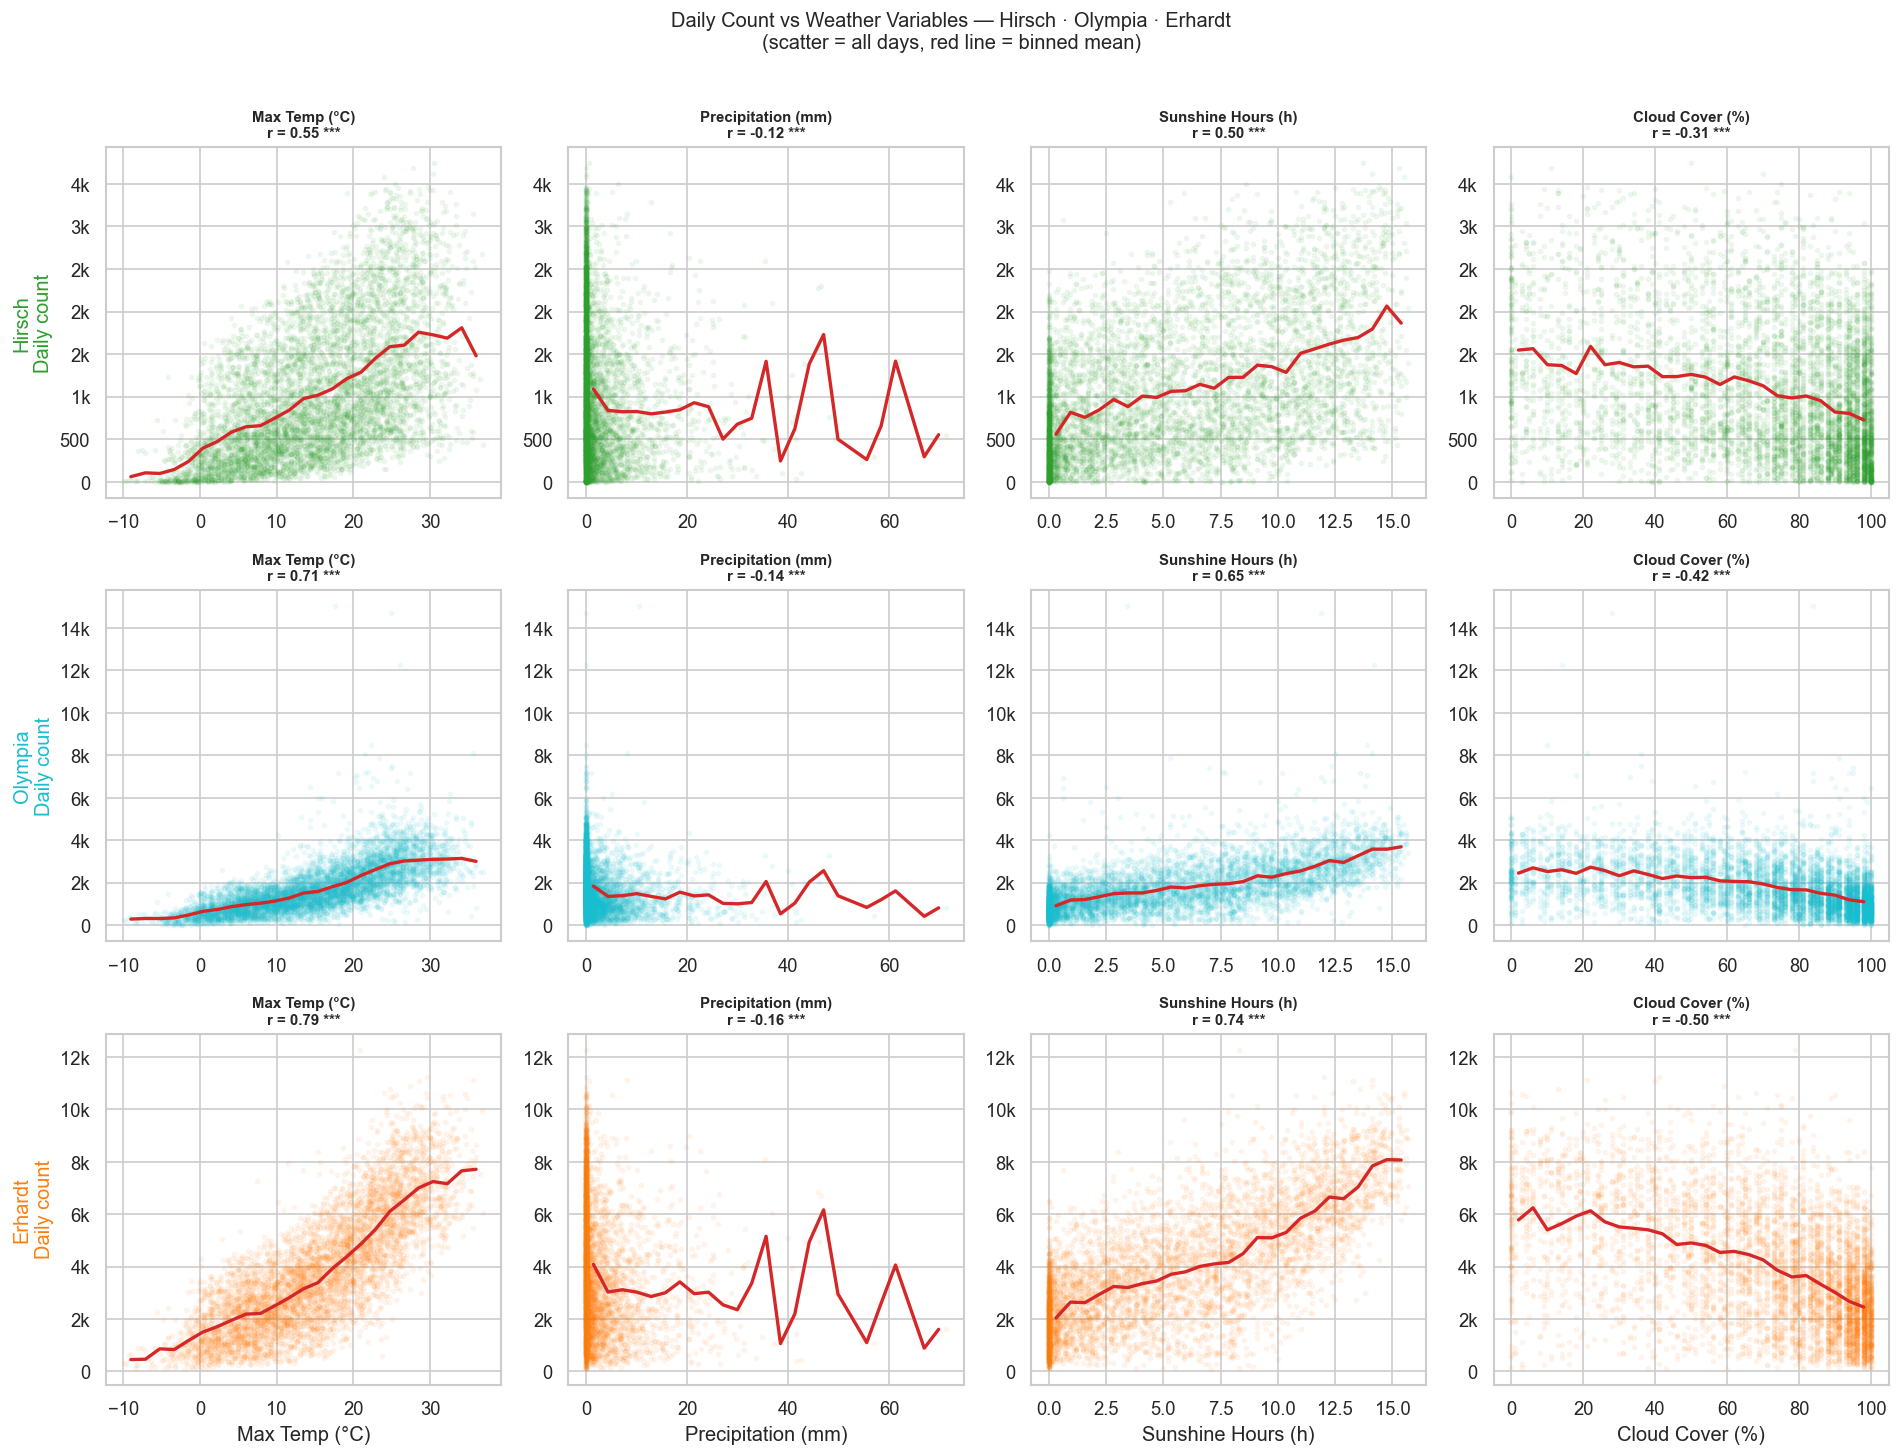

  saved → results/figures/nb02_fig_11_weather_scatter.png


In [14]:
weather_vars  = ['max_temp', 'precipitation', 'sunshine_hours', 'cloud_cover']
weather_label = {
    'max_temp'       : 'Max Temp (°C)',
    'precipitation'  : 'Precipitation (mm)',
    'sunshine_hours' : 'Sunshine Hours (h)',
    'cloud_cover'    : 'Cloud Cover (%)',
}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, st in enumerate(PRIMARY):
    st_data = df[(df['station'] == st) & df['total'].notna()].copy()

    for col_idx, col in enumerate(weather_vars):
        ax = axes[row, col_idx]
        x  = st_data[col].dropna()
        y  = st_data.loc[x.index, 'total']

        ax.scatter(x, y, alpha=0.06, s=6, color=COLORS[st], rasterized=True)

        try:
            bins   = pd.cut(x, bins=25)
            binned = y.groupby(bins, observed=False).mean().dropna()
            centers = [(b.left + b.right) / 2 for b in binned.index]
            ax.plot(centers, binned.values, color='#d62728', linewidth=2.0, zorder=3)
        except Exception:
            pass

        r, p = stats.pearsonr(x, y)
        sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.set_title(f'{weather_label[col]}\nr = {r:.2f} {sig}', fontsize=9)
        ax.set_xlabel(weather_label[col] if row == 2 else '')
        ax.set_ylabel(f'{st}\nDaily count' if col_idx == 0 else '')
        if col_idx == 0:
            ax.yaxis.label.set_color(COLORS[st])
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k' if v >= 1000 else f'{v:.0f}'))

fig.suptitle('Daily Count vs Weather Variables — Hirsch · Olympia · Erhardt\n'
             '(scatter = all days, red line = binned mean)', fontsize=12, y=1.01)
plt.tight_layout()
savefig('fig_11_weather_scatter')

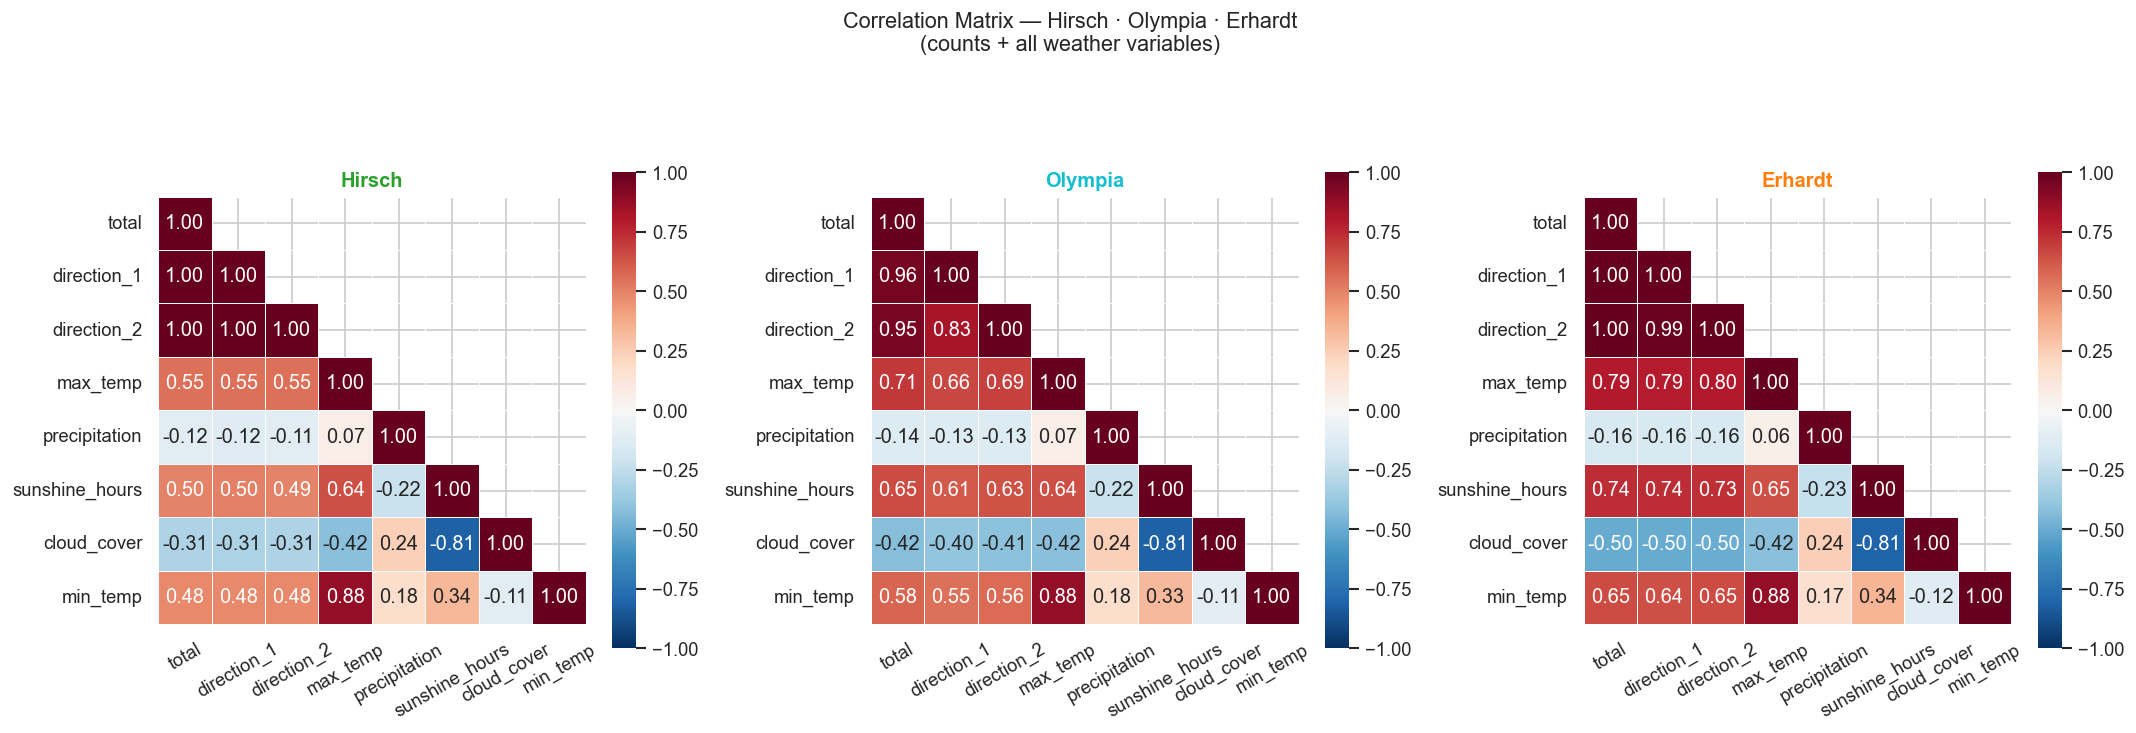

  saved → results/figures/nb02_fig_12_correlation_matrix.png


In [15]:
all_wx = ['total', 'direction_1', 'direction_2'] + weather_vars + ['min_temp']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, st in zip(axes, PRIMARY):
    corr = df[(df['station'] == st) & df['total'].notna()][all_wx].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.heatmap(
        corr, ax=ax,
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        mask=mask, square=True, linewidths=0.3,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(st, fontsize=12, fontweight='bold', color=COLORS[st])
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Correlation Matrix — Hirsch · Olympia · Erhardt\n'
             '(counts + all weather variables)', fontsize=13, y=1.02)
plt.tight_layout()
savefig('fig_12_correlation_matrix')

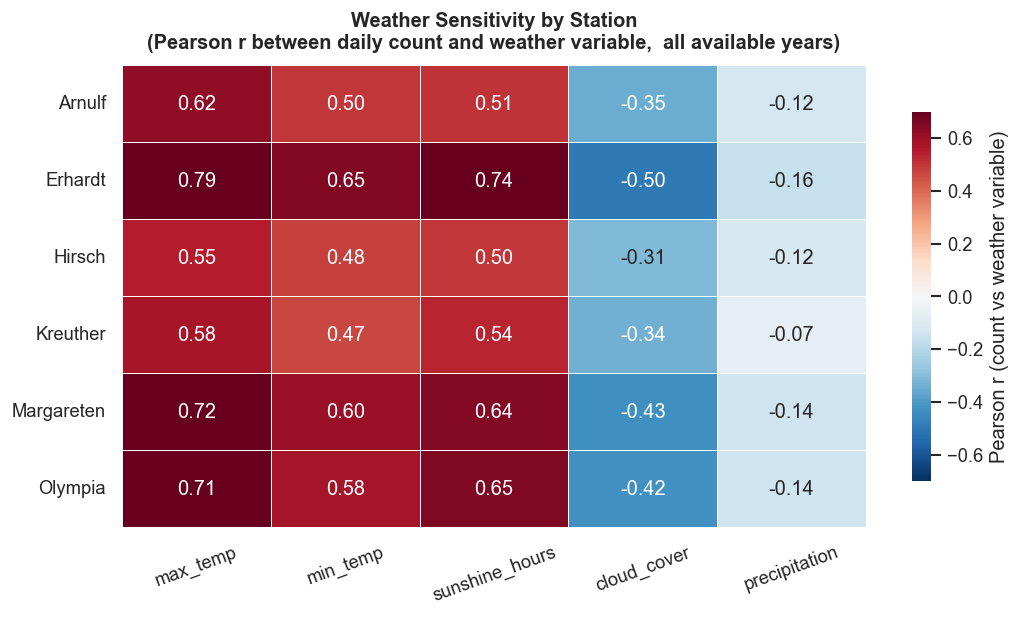

  saved → results/figures/nb02_fig_13_weather_sensitivity.png


In [16]:
# ── weather sensitivity comparison across stations ────────────────────────────
corr_records = []
for st in STATIONS:
    sub = df[(df['station'] == st) & df['total'].notna()]
    for col in ['max_temp', 'min_temp', 'precipitation', 'cloud_cover', 'sunshine_hours']:
        valid = sub[['total', col]].dropna()
        if len(valid) > 100:
            r, p = stats.pearsonr(valid[col], valid['total'])
            corr_records.append({'station': st, 'variable': col, 'r': r})

corr_df = pd.DataFrame(corr_records)
sens_pivot = corr_df.pivot(index='station', columns='variable', values='r')
cols_order = ['max_temp', 'min_temp', 'sunshine_hours', 'cloud_cover', 'precipitation']
sens_pivot = sens_pivot[cols_order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    sens_pivot, ax=ax,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7,
    linewidths=0.3,
    cbar_kws={'label': 'Pearson r (count vs weather variable)', 'shrink': 0.8},
)
ax.set_title('Weather Sensitivity by Station\n'
             '(Pearson r between daily count and weather variable,  all available years)', pad=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
savefig('fig_13_weather_sensitivity')

### Weather Correlation Findings

**Priority regressors (strongest raw correlations on Hirsch):**

| Variable | r | Interpretation |
|---|---|---|
| `max_temp` | +0.55 | Strong: warm days bring more cyclists |
| `sunshine_hours` | +0.51 | Strong: sunshine encourages cycling |
| `min_temp` | +0.50 | Moderate-strong: cold nights correlate with cold days |
| `cloud_cover` | −0.35 | Moderate: overcast skies deter cycling |
| `precipitation` | −0.12 | Weak in absolute value, but nonlinear |

**Caution — weather confounds with seasonality:** `max_temp` and `sunshine_hours` are themselves seasonal, so their raw correlations with daily counts partly reflect shared seasonality rather than causal weather effects. To isolate the genuine daily weather signal, models should be tested with and without weather regressors after controlling for the seasonal baseline.

**Station sensitivity is broadly uniform** — all stations respond to temperature and sunshine in the same direction. Olympia (recreational) shows slightly stronger temperature sensitivity than Hirsch (commuter), consistent with recreational cycling being more weather-discretionary.

**Recommended regressors for the XGBoost/RF models:** `max_temp`, `sunshine_hours`, `precipitation` (log1p-transformed). Avoid `min_temp` (collinear with `max_temp`) and `cloud_cover` (collinear with `sunshine_hours`).

---
## 5 · Station Comparison

**Question:** Are these six stations distinct enough to model separately, or can we pool them?

In [17]:
# ── comprehensive per-station statistics ─────────────────────────────────────
rows = []
for st in STATIONS:
    sub = df[(df['station'] == st) & df['total'].notna()]

    ann_sub = []
    yr_range = range(2020, 2024) if st == 'Kreuther' else range(2015, 2024)
    for yr in yr_range:
        s = sub[sub['year'] == yr]
        if s['total'].notna().sum() >= 300:
            ann_sub.append((yr, s['total'].sum()))
    if len(ann_sub) >= 4:
        xs, ys = zip(*ann_sub)
        sl, ic, r, *_ = stats.linregress(xs, ys)
        growth = sl / np.mean(ys) * 100
        r2 = r ** 2
    else:
        growth, r2 = np.nan, np.nan

    summer = sub[sub['month'].isin([6, 7, 8])]['total'].median()
    winter = sub[sub['month'].isin([12, 1, 2])]['total'].median()
    wd = sub[~sub['is_wknd']]['total'].mean()
    we = sub[sub['is_wknd']]['total'].mean()

    rows.append({
        'Station'       : st,
        'N days'        : f"{len(sub):,}",
        'Mean /day'     : f"{sub['total'].mean():.0f}",
        'Median /day'   : f"{sub['total'].median():.0f}",
        'Std'           : f"{sub['total'].std():.0f}",
        'CV (%)'        : f"{sub['total'].std() / sub['total'].mean() * 100:.0f}",
        'Max day'       : f"{sub['total'].max():.0f}",
        'S/W ratio'     : f"{summer / winter:.1f}×",
        'WD/WE ratio'   : f"{wd / we:.2f}×",
        'Growth %/yr'   : f"{growth:.1f}" if not np.isnan(growth) else '—',
        'Trend R²'      : f"{r2:.2f}" if not np.isnan(r2) else '—',
        'Miss. days'    : f"{sub['total'].isna().sum() + (df[(df['station']==st)]['total'].isna().sum())}",
    })

stats_table = pd.DataFrame(rows).set_index('Station')
stats_table

,N days,Mean /day,Median /day,Std,CV (%),Max day,S/W ratio,WD/WE ratio,Growth %/yr,Trend R²,Miss. days
Station,,,,,,,,,,,
Arnulf,"6,100",1104,1000,721,65,4514,3.0×,1.73×,2.0,0.22,412
Erhardt,"5,312",3853,3499,2247,58,12283,3.4×,1.30×,5.1,0.93,24
Hirsch,"5,989",1033,847,771,75,3745,3.2×,2.02×,7.8,0.88,554
Kreuther,"5,411",397,305,318,80,1787,4.2×,1.64×,—,—,309
Margareten,"4,435",2704,2611,1446,53,7652,2.9×,1.57×,6.0,0.88,132
Olympia,"6,039",1738,1517,1144,66,15009,3.6×,1.16×,5.8,0.77,504


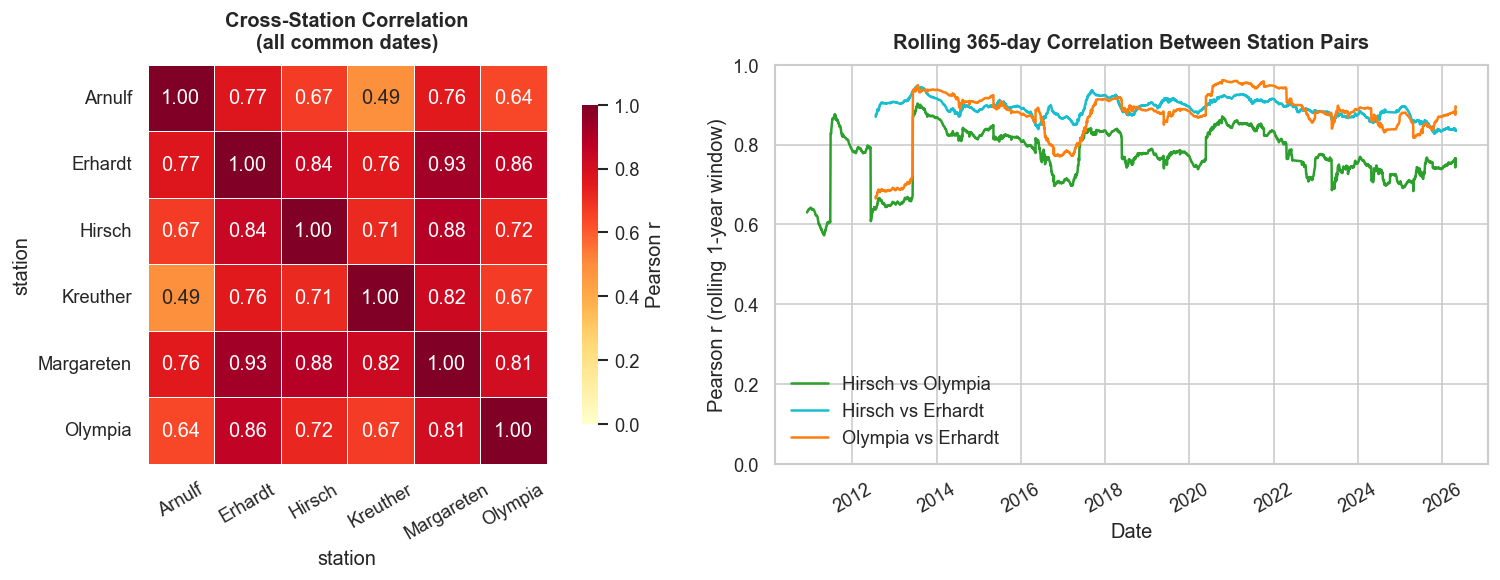

  saved → results/figures/nb02_fig_14_cross_station_correlation.png


In [18]:
# ── cross-station correlation and rolling correlation ────────────────────────
pivot = df.pivot_table(index='date', columns='station', values='total')
cross_corr = pivot.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cross_corr, ax=axes[0],
    annot=True, fmt='.2f',
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, square=True,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
)
axes[0].set_title('Cross-Station Correlation\n(all common dates)', pad=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

pairs = [('Hirsch', 'Olympia'), ('Hirsch', 'Erhardt'), ('Olympia', 'Erhardt')]
pair_colors = ['#2ca02c', '#17becf', '#ff7f0e']

for (s1, s2), col in zip(pairs, pair_colors):
    common = pivot[[s1, s2]].dropna()
    roll_r = common[s1].rolling(365).corr(common[s2])
    axes[1].plot(roll_r.index, roll_r.values, color=col,
                 linewidth=1.5, label=f'{s1} vs {s2}')

axes[1].set_title('Rolling 365-day Correlation Between Station Pairs', pad=10)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Pearson r (rolling 1-year window)')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=30)

plt.tight_layout()
savefig('fig_14_cross_station_correlation')

### Station Comparison Findings

**Scale is radically different:** Erhardt (mean 3,900–4,800/day) and Olympia (mean ~1,800/day) carry 3–10× more cyclists than Arnulf or Hirsch. Any pooled model must normalise by station or use station-level fixed effects.

**Profile taxonomy:**
- **Commuter stations (Arnulf, Hirsch):** WD/WE ratio ≥ 1.7×, lower CV, more predictable, minimal weather discretion
- **Recreational/mixed (Olympia, Erhardt):** WD/WE ratio ≤ 1.3×, higher CV, stronger weekend peaks, more weather-sensitive
- **Kreuther:** Outlier — post-2020 data resembles a new station; pre-2020 data is a different system

**High cross-station correlation:** All pairs show r > 0.80, meaning they share a common seasonal signal (Munich weather). This is not surprising, but it means that weather regressors will be highly informative for all stations. The rolling-correlation plot confirms this is stable over time.

**Implication:** Separate models per station are justified (scale and profile differ), but a multi-variate or hierarchical model could leverage the shared seasonality signal for regularisation.

---
## 6 · Structural Breaks and Anomalies

**Question:** What shocks will the models need to handle, and which represent forecasting challenges vs. modelling gotchas?

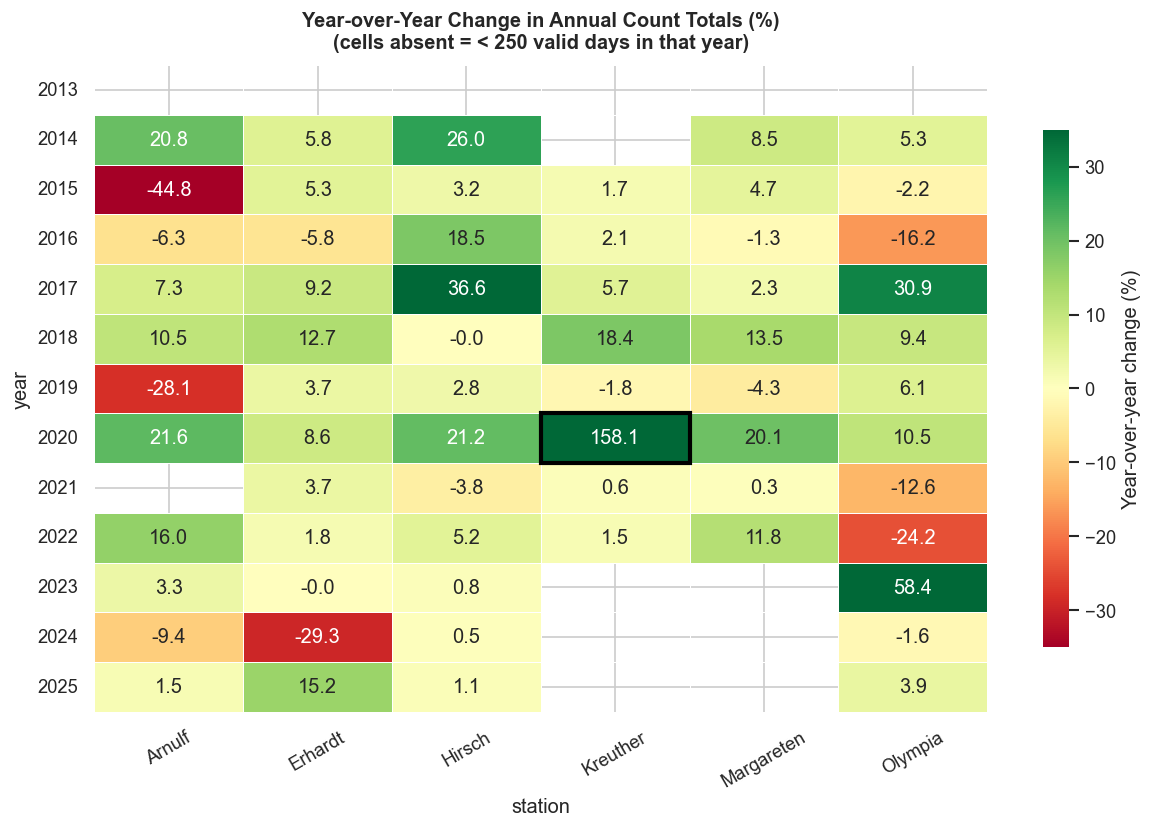

  saved → results/figures/nb02_fig_15_yoy_change_heatmap.png


In [19]:
# ── year-over-year change heatmap (annual totals, ≥300 valid days) ────────────
ann2 = []
for st in STATIONS:
    for yr in range(2013, 2026):
        sub = df[(df['station'] == st) & (df['year'] == yr)]
        nv  = sub['total'].notna().sum()
        if nv >= 250:
            ann2.append({'station': st, 'year': yr, 'total': sub['total'].sum()})

ann2_df = (pd.DataFrame(ann2).sort_values(['station', 'year']))
ann2_df['yoy'] = ann2_df.groupby('station')['total'].pct_change() * 100

yoy_pivot = ann2_df.pivot(index='year', columns='station', values='yoy')

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    yoy_pivot,
    ax=ax,
    annot=True, fmt='.1f',
    cmap='RdYlGn', center=0, vmin=-35, vmax=35,
    linewidths=0.3,
    cbar_kws={'label': 'Year-over-year change (%)', 'shrink': 0.8},
)
ax.set_title('Year-over-Year Change in Annual Count Totals (%)\n'
             '(cells absent = < 250 valid days in that year)', pad=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

if 2020 in yoy_pivot.index and 'Kreuther' in yoy_pivot.columns:
    xi = list(yoy_pivot.columns).index('Kreuther')
    yi = list(yoy_pivot.index).index(2020)
    ax.add_patch(plt.Rectangle((xi, yi), 1, 1, fill=False, edgecolor='black',
                                linewidth=2.5, zorder=5))

savefig('fig_15_yoy_change_heatmap')

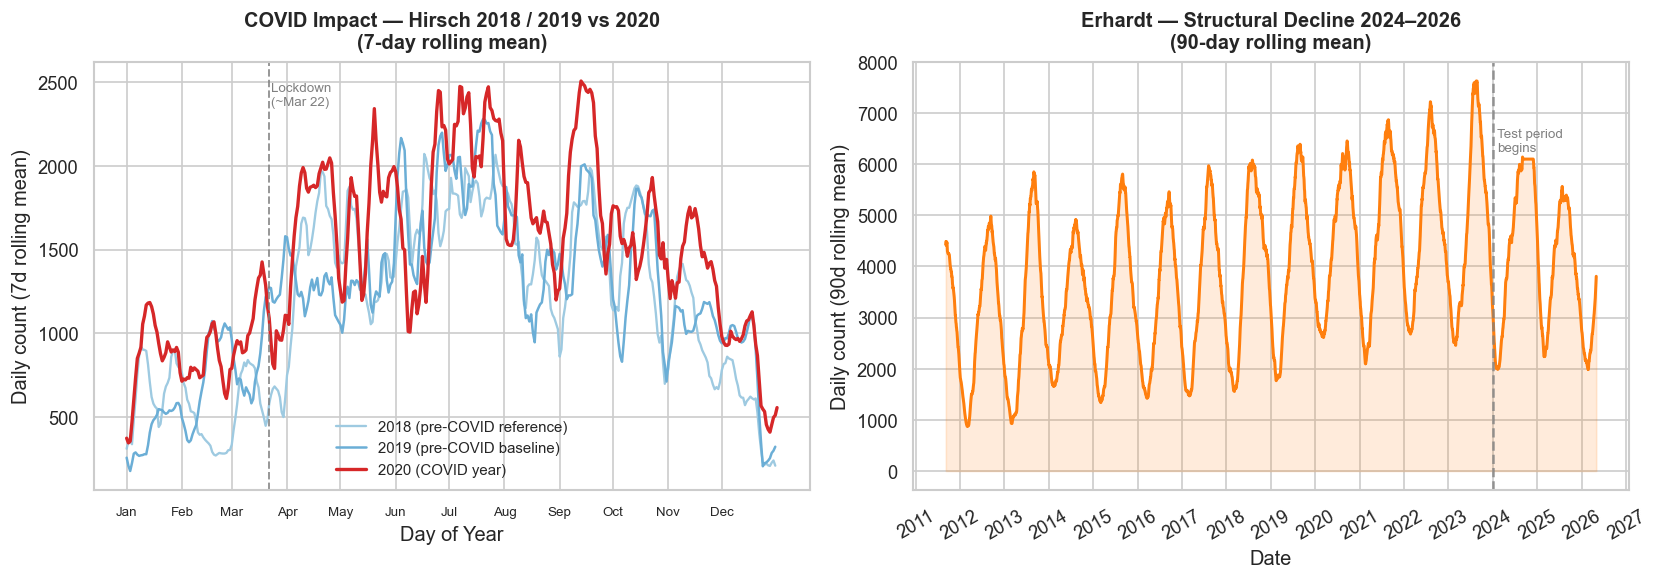

  saved → results/figures/nb02_fig_16_structural_anomalies.png


In [20]:
# ── COVID 2020 analysis and anomaly detection ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: COVID comparison — Hirsch 2018, 2019, 2020
# 2018 added as additional pre-COVID reference to show the growth trajectory context
for yr, color, label, lw in [
    (2018, '#9ecae1', '2018 (pre-COVID reference)', 1.4),
    (2019, '#6baed6', '2019 (pre-COVID baseline)',  1.5),
    (2020, '#d62728', '2020 (COVID year)',           2.0),
]:
    sub = df[(df['station'] == 'Hirsch') & (df['year'] == yr) &
             df['total'].notna()].sort_values('doy')
    if len(sub) < 100:
        continue
    r7 = sub.set_index('doy')['total'].rolling(7, min_periods=3, center=True).mean()
    axes[0].plot(r7.index, r7.values, color=color, linewidth=lw, label=label)

# Lockdown marker
axes[0].axvline(81, color='grey', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].text(82, axes[0].get_ylim()[1] * 0.9, 'Lockdown\n(~Mar 22)', fontsize=8, color='grey')
axes[0].set_title('COVID Impact — Hirsch 2018 / 2019 vs 2020\n(7-day rolling mean)', pad=8)
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Daily count (7d rolling mean)')
axes[0].legend(fontsize=9)
axes[0].set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
axes[0].set_xticklabels(MONTHS, fontsize=8)

# Right: Erhardt 2022–2026 structural decline
erhardt_sub = df[(df['station'] == 'Erhardt') & df['total'].notna()].copy()
erhardt_sub = erhardt_sub.sort_values('date')
erhardt_r90 = erhardt_sub.set_index('date')['total'].rolling(90, min_periods=45).mean()
axes[1].plot(erhardt_r90.index, erhardt_r90.values,
             color=COLORS['Erhardt'], linewidth=1.8)
axes[1].fill_between(erhardt_r90.index, erhardt_r90.values,
                     alpha=0.15, color=COLORS['Erhardt'])
axes[1].axvline(pd.Timestamp('2024-01-01'), color='grey',
                linestyle='--', linewidth=1.5, alpha=0.8)
axes[1].text(pd.Timestamp('2024-02-01'), erhardt_r90.max() * 0.82,
             'Test period\nbegins', fontsize=8, color='grey')
axes[1].set_title('Erhardt — Structural Decline 2024–2026\n(90-day rolling mean)', pad=8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily count (90d rolling mean)')
axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=30)

plt.tight_layout()
savefig('fig_16_structural_anomalies')

### Structural Break and Anomaly Findings

**COVID 2020 — counter-intuitive result:** Munich cycling counts *increased* in 2020 relative to 2019 on most stations. The spring lockdown caused a brief dip (visible in the Hirsch plot around March–April), but this was rapidly offset by a summer cycling boom — a modal shift as commuters abandoned public transport. This is consistent with broader European cycling trends. **Implication:** no COVID dummy is needed for Munich; 2020 is a useful training year.

**Arnulf 2021 — sensor failure:** Only November–December have valid data. This is a modelling-set challenge, not a real-world cycling event. Options: (a) interpolate from weather-based predictions, (b) drop 2021 from Arnulf training, (c) use a missing-data indicator feature. The preferred approach for SARIMA is to interpolate; for XGBoost/RF, a binary `sensor_ok` flag.

**Kreuther 2020 — counter relocation (boxed in heatmap):** The +157% YoY jump cannot be attributed to organic growth or any known external event. This is almost certainly a new counter location measuring a higher-traffic segment. For thesis purposes, treat Kreuther as two distinct datasets: pre-2020 (archive) and 2020–2025 (modelling).

**Erhardt 2024–2025 — genuine structural decline:** The mean test-period count is −17.1% below 2023 (−8.4% for 2024, ~−19% for 2025 specifically vs 2023). Possible causes: road works, changed routing, or reduced cycling infrastructure. This decline lands in the **test set**, making Erhardt the most challenging and scientifically interesting forecasting target.

---
## 7 · Train / Validation / Test Split

**Proposed split:**
- **Train:** 2013–2022 (10 years, ≈ 21,000 station-days)
- **Validation:** 2023 (1 year — for hyperparameter tuning and model selection)
- **Test:** 2024–2025 (2 years — held-out final evaluation)

Rationale: 2013 chosen as training start because all 4 primary stations are active and relatively complete by then. The 10-year training window provides sufficient seasonal cycles. The two-year test period captures the Erhardt structural break and provides stable estimates of forecast skill across different conditions.

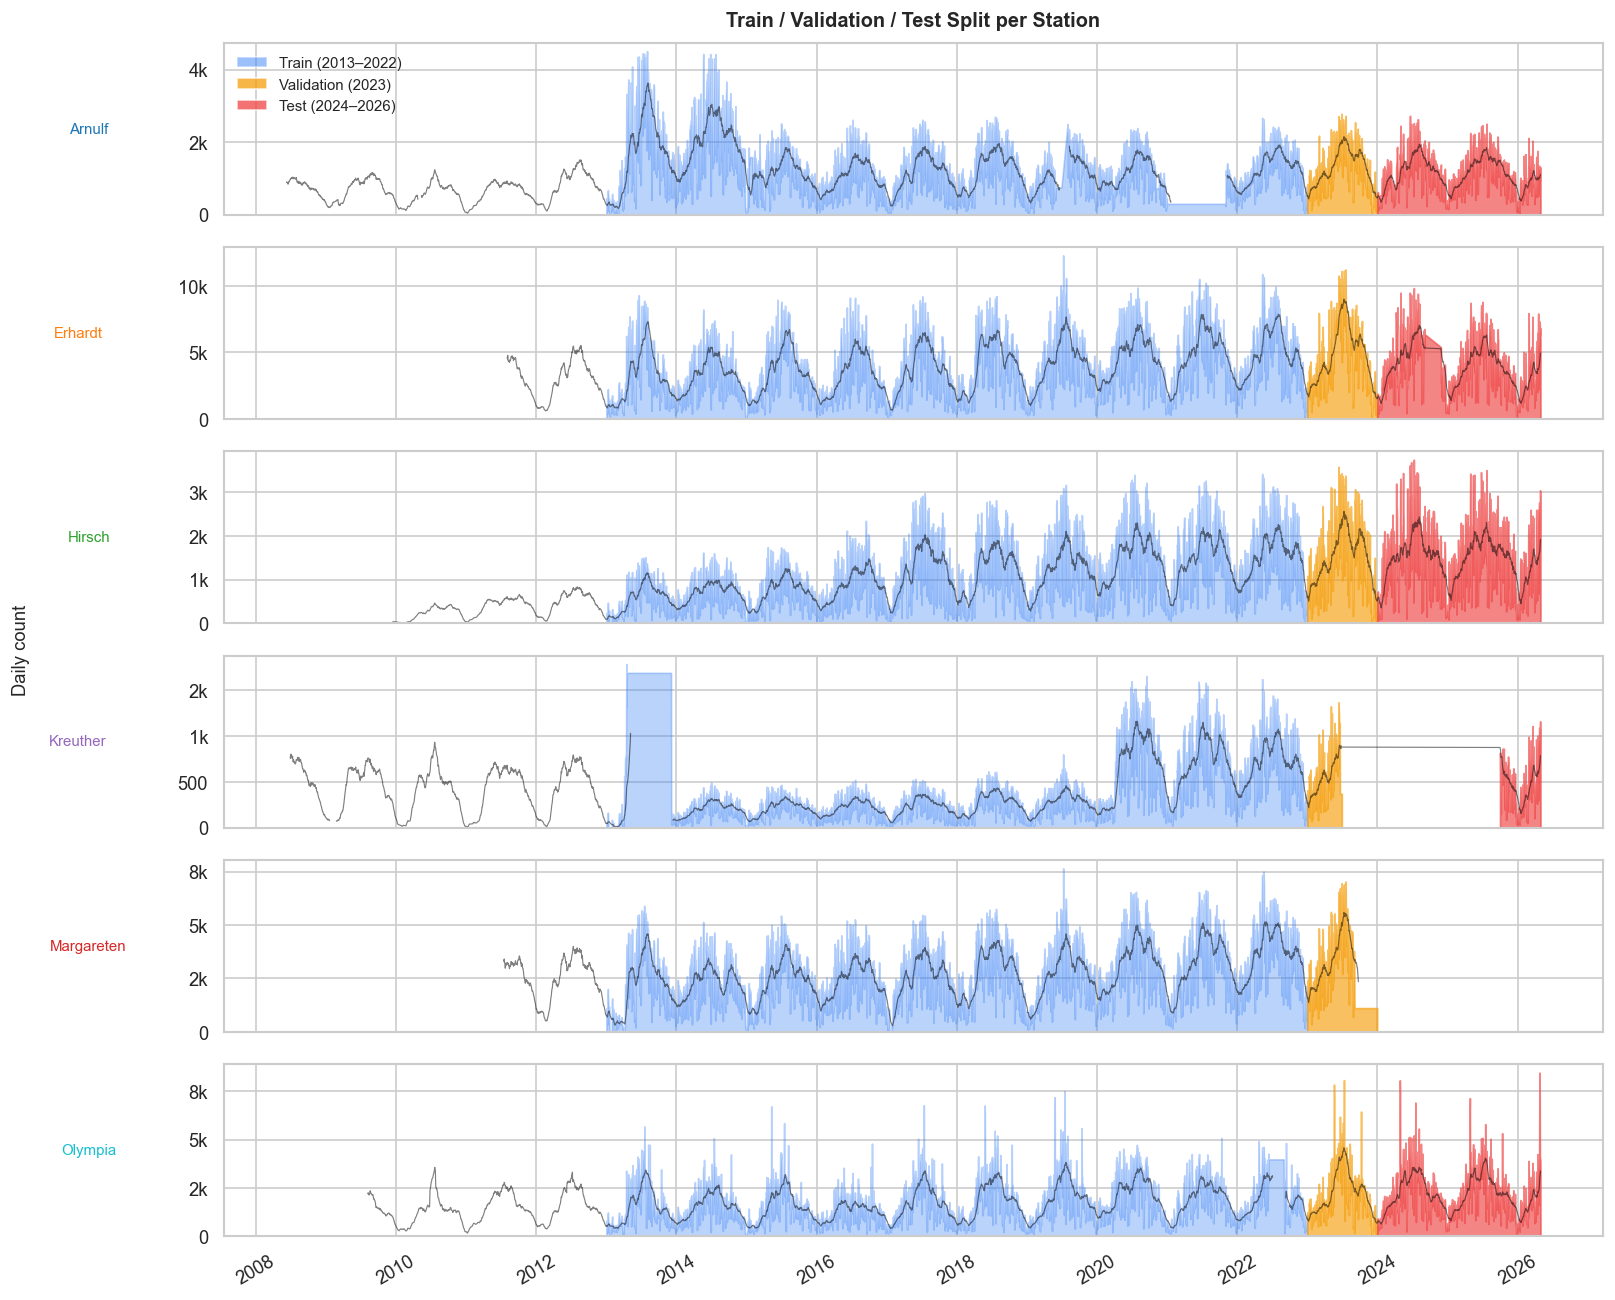

  saved → results/figures/nb02_fig_17_train_val_test_split.png


In [21]:
fig, axes = plt.subplots(len(STATIONS), 1, figsize=(14, 11), sharex=True)

split_def = {
    'Train'     : ('#3b82f6', 0.35, '2013-01-01', TRAIN_END),
    'Validation': ('#f59e0b', 0.65, VAL_START,    VAL_END),
    'Test'      : ('#ef4444', 0.65, TEST_START,   TEST_END),
}

for ax, st in zip(axes, STATIONS):
    st_data = df[df['station'] == st].sort_values('date')
    r30 = st_data.set_index('date')['total'].rolling(30, min_periods=10).mean()

    for split_name, (color, alpha, start, end) in split_def.items():
        mask = (st_data['date'] >= start) & (st_data['date'] <= end)
        chunk = st_data[mask]
        if len(chunk):
            ax.fill_between(chunk['date'],
                            chunk['total'].ffill().fillna(0),
                            color=color, alpha=alpha)

    # 30d rolling mean overlay
    ax.plot(r30.index, r30.values, color='black', linewidth=0.7, alpha=0.5)
    ax.set_ylabel(st, rotation=0, labelpad=60, va='center', fontsize=9,
                  color=COLORS[st])
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}'))

legend_patches = [
    mpatches.Patch(facecolor='#3b82f6', alpha=0.5, label='Train (2013–2022)'),
    mpatches.Patch(facecolor='#f59e0b', alpha=0.75, label='Validation (2023)'),
    mpatches.Patch(facecolor='#ef4444', alpha=0.75, label='Test (2024–2026)'),
]
axes[0].legend(handles=legend_patches, loc='upper left', fontsize=9)
axes[0].set_title('Train / Validation / Test Split per Station', pad=10)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=30)
fig.text(0.04, 0.5, 'Daily count', va='center', rotation='vertical', fontsize=11)
plt.tight_layout(rect=[0.05, 0, 1, 1])
savefig('fig_17_train_val_test_split')

In [22]:
# ── split statistics ──────────────────────────────────────────────────────────
split_rows = []
for st in STATIONS:
    for split_nm, start, end in [
        ('Train (2013–2022)', '2013-01-01', TRAIN_END),
        ('Val (2023)',        VAL_START,    VAL_END),
        ('Test (2024–2026)',  TEST_START,   TEST_END),
    ]:
        sub = df[
            (df['station'] == st) &
            (df['date'] >= start) & (df['date'] <= end) &
            df['total'].notna()
        ]
        if len(sub) == 0:
            split_rows.append({'Station': st, 'Split': split_nm,
                                'N valid days': 0, 'Mean': '—', 'Total': '—'})
        else:
            split_rows.append({
                'Station'    : st,
                'Split'      : split_nm,
                'N valid days': len(sub),
                'Mean /day'  : f"{sub['total'].mean():.0f}",
                'Ann. total' : f"{sub['total'].sum() / max(1, sub['year'].nunique()):.0f}",
            })

split_stats = pd.DataFrame(split_rows)
split_stats.pivot_table(
    index='Station', columns='Split', values='N valid days', aggfunc='first'
)[['Train (2013–2022)', 'Val (2023)', 'Test (2024–2026)']]

Split,Train (2013–2022),Val (2023),Test (2024–2026)
Station,,,
Arnulf,3255,365,851
Erhardt,3652,365,769
Hirsch,3652,365,851
Kreuther,3417,171,212
Margareten,3645,247,0
Olympia,3572,365,851


### Split Verification

- **Margareten** has 0 days in test → confirmed exclusion from primary modelling
- **Arnulf** has a large gap in the 2021 training block — models must handle or impute this
- **Erhardt** has a structural break at the train/test boundary (2024) — this makes it a hard test case that will distinguish models with good uncertainty quantification from those that don't
- All other stations have sufficient and consistent training data

---
## 8 · Modeling Strategy

### Station Selection for Thesis

Based on the full EDA, here is the recommended station selection:

In [23]:
# ── final station selection summary table ────────────────────────────────────
selection = pd.DataFrame([
    {
        'Station'      : 'Hirsch',
        'Role'         : '★ Prototype (primary)',
        'Profile'      : 'Commuter',
        'Data quality' : '★★★★★ (best)',
        'Growth'       : '+7.8 %/yr (steady)',
        'Test challenge': 'Clean — pure forecasting test',
        'Reason'       : 'Cleanest data, steady growth, ideal for initial model dev',
    },
    {
        'Station'      : 'Olympia',
        'Role'         : '★ Primary',
        'Profile'      : 'Recreational',
        'Data quality' : '★★★★☆ (good)',
        'Growth'       : '+5.8 %/yr (steady)',
        'Test challenge': 'Moderate — stable test period',
        'Reason'       : 'Recreational profile contrasts Hirsch; good coverage',
    },
    {
        'Station'      : 'Arnulf',
        'Role'         : '★ Primary',
        'Profile'      : 'Commuter',
        'Data quality' : '★★★☆☆ (2021 gap)',
        'Growth'       : '+2.0 %/yr (mature)',
        'Test challenge': 'Low — near-mature corridor',
        'Reason'       : 'Longest history; mature corridor; 2021 gap tests imputation',
    },
    {
        'Station'      : 'Erhardt',
        'Role'         : '★ Primary (hard test)',
        'Profile'      : 'Mixed/Commuter',
        'Data quality' : '★★★★☆ (good through 2023)',
        'Growth'       : '+5.1 %/yr → structural decline',
        'Test challenge': '★★★★★ (hardest — −17.1% test mean decline)',
        'Reason'       : 'Structural break tests model robustness to change-points',
    },
    {
        'Station'      : 'Kreuther',
        'Role'         : '⚠ Limited (2020+ only)',
        'Profile'      : 'Unknown (relocated)',
        'Data quality' : '★★★☆☆ (break in 2020)',
        'Growth'       : '+20.9 %/yr = artefact of relocation',
        'Test challenge': 'Misleading — apparent high growth is not organic',
        'Reason'       : 'Use only if explicitly modelling post-break period',
    },
    {
        'Station'      : 'Margareten',
        'Role'         : '✗ Excluded',
        'Profile'      : 'Urban leisure',
        'Data quality' : '★★★☆☆ (ends 2023)',
        'Growth'       : '+6.0 %/yr',
        'Test challenge': '✗ No test set data',
        'Reason'       : 'No 2024/2025 data — cannot be evaluated',
    },
]).set_index('Station')

selection

,Role,Profile,Data quality,Growth,Test challenge,Reason
Station,,,,,,
Hirsch,★ Prototype (primary),Commuter,★★★★★ (best),+7.8 %/yr (steady),Clean — pure forecasting test,"Cleanest data, steady growth, ideal for initia..."
Olympia,★ Primary,Recreational,★★★★☆ (good),+5.8 %/yr (steady),Moderate — stable test period,Recreational profile contrasts Hirsch; good co...
Arnulf,★ Primary,Commuter,★★★☆☆ (2021 gap),+2.0 %/yr (mature),Low — near-mature corridor,Longest history; mature corridor; 2021 gap tes...
Erhardt,★ Primary (hard test),Mixed/Commuter,★★★★☆ (good through 2023),+5.1 %/yr → structural decline,★★★★★ (hardest — −17.1% test mean decline),Structural break tests model robustness to cha...
Kreuther,⚠ Limited (2020+ only),Unknown (relocated),★★★☆☆ (break in 2020),+20.9 %/yr = artefact of relocation,Misleading — apparent high growth is not organic,Use only if explicitly modelling post-break pe...
Margareten,✗ Excluded,Urban leisure,★★★☆☆ (ends 2023),+6.0 %/yr,✗ No test set data,No 2024/2025 data — cannot be evaluated


### Evidence-Based Modeling Decisions

#### What makes Munich cycling data interesting for forecasting

1. **Very strong annual seasonality (dominant):** Summer-to-winter ratios of 3–4× mean the seasonal component explains most of the variance. Any model that doesn't capture the annual cycle will have systematically large errors in winter/summer.

2. **Two mandatory seasonal periods:** Weekly (s=7) and annual (s≈365). ACF confirms both. SARIMA should specify both, or use Fourier terms as external regressors for the annual component.

3. **Multiplicative seasonality:** The month × weekday heatmap (Hirsch) shows the weekend dip is *proportionally* larger in summer. This argues for either multiplicative decomposition (Prophet) or log-transforming the target before fitting additive models.

4. **Structural breaks are real and varied:** One break is a data artefact (Kreuther 2020), one is an organic demand shift (Erhardt 2024–25), and one is a sensor failure (Arnulf 2021). Good models need to handle all three types differently.

---

#### Recommended forecasting architecture

**Statistical baseline (SARIMA/Prophet):**
- SARIMA: `(p,d,q)(P,D,Q)[7]` with Fourier terms for annual seasonality
- Prophet: multiplicative mode, both weekly and annual seasonality, `max_temp` + `sunshine_hours` as additional regressors
- Use Hirsch as the prototype station to tune, then replicate across primaries

**ML models (XGBoost / Random Forest):**
- Features: `doy`, `weekday`, `month`, `year`, `is_weekend`, `lag_7`, `lag_14`, `lag_365`, `rolling_mean_7`, `rolling_mean_28`, `max_temp`, `sunshine_hours`, `precipitation` (log1p)
- For Arnulf: add binary `sensor_ok` flag (0 for 2021 Jan–Oct)
- For Erhardt: no special treatment — let the model learn the level shift from 2024 data

**Recommended regressors:** `max_temp` (r=0.55) > `sunshine_hours` (r=0.51) > `precipitation` (r=−0.12, nonlinear — use log1p). Drop `min_temp` (collinear with `max_temp`) and `cloud_cover` (collinear with `sunshine_hours` — see Section 4). Consider interaction `max_temp × is_weekend` for recreational stations.

**Expected challenges by station:**

| Station | Main Challenge | Mitigation |
|---------|---------------|------------|
| Hirsch  | None — best case | Benchmark model here first |
| Olympia | Higher weather variance | Include weather regressors |
| Arnulf  | 2021 data gap in training | Linear interpolation or missing indicator |
| Erhardt | −17.1% test-period mean decline | Test model calibration and PI coverage |

**Forecast horizons:** 7-day horizon favours SARIMA/Prophet (leverage recent autocorrelation). 30-day horizon favours tree models (longer-range weather + calendar signals dominate over autocorrelation).

---

*All figures saved to `results/figures/`. Proceed to Phase 3: Feature Engineering and Model Training.*

---
## Thesis figures: per-station time-series overviews (nb02_fig_18–20)

One figure per primary station. Shades train/val/test, highlights gaps in red.

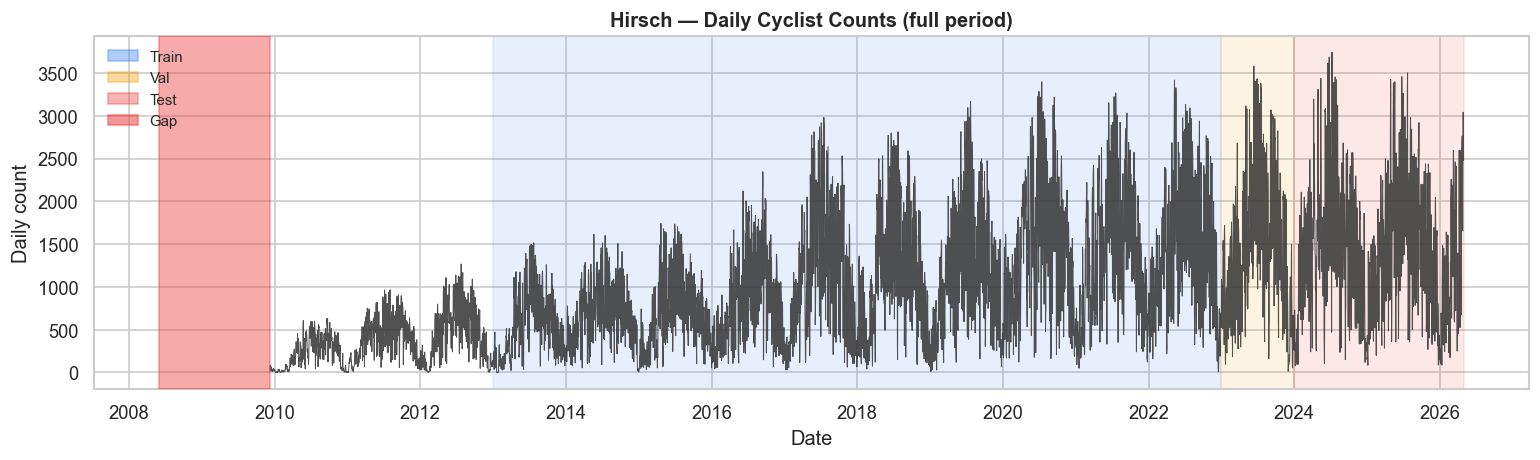

  saved → results/figures/nb02_fig_18_time_series_overview_hirsch.png


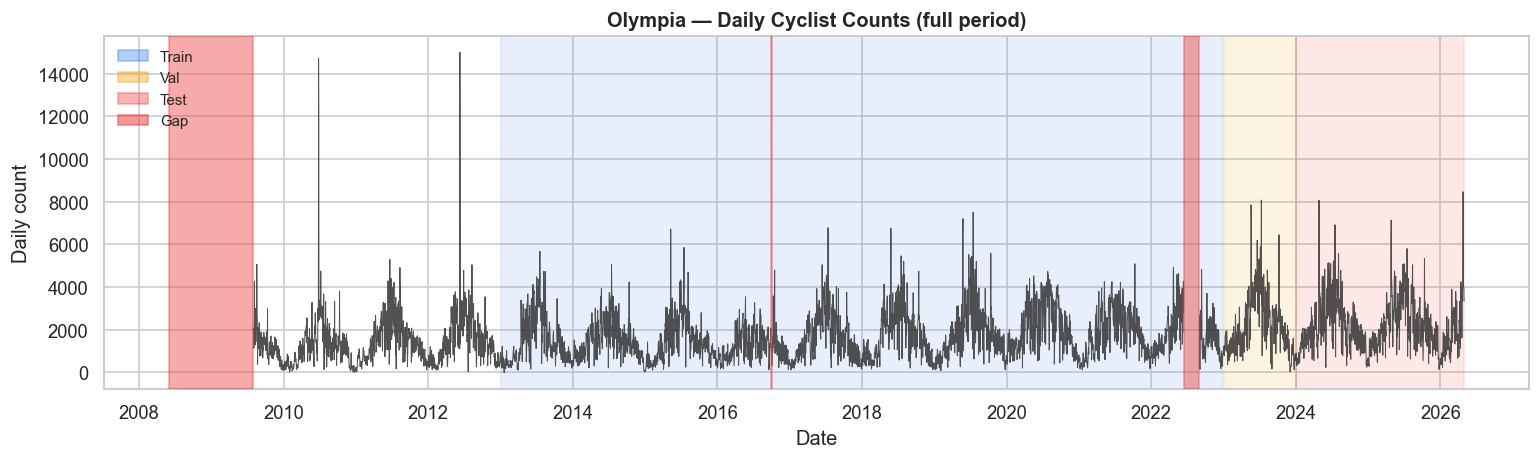

  saved → results/figures/nb02_fig_19_time_series_overview_olympia.png


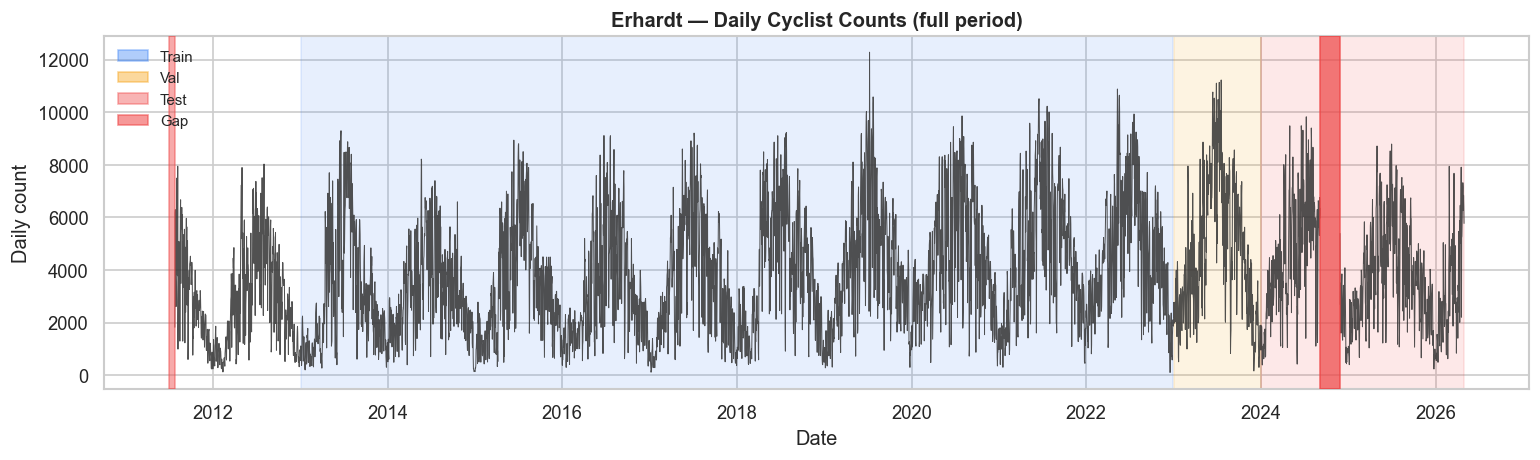

  saved → results/figures/nb02_fig_20_time_series_overview_erhardt.png


In [24]:
SPLIT_COLORS = {'Train': '#3b82f6', 'Val': '#f59e0b', 'Test': '#ef4444'}

# ── nb02_fig_18/19/20 — time-series overview, one per station ────────────────
import matplotlib.patches as mpatches

PRIMARY    = ['Hirsch', 'Olympia', 'Erhardt']
GAP_START  = pd.Timestamp('2024-09-06')
GAP_END    = pd.Timestamp('2024-11-26')

for fig_num, st in zip([18, 19, 20], PRIMARY):
    sdf  = df[df['station'] == st].set_index('date').sort_index()
    full = sdf.reindex(pd.date_range(sdf.index.min(), sdf.index.max()))

    fig, ax = plt.subplots(figsize=(13, 4))

    spans = [
        (max(full.index[0], pd.Timestamp(TRAIN_END) - pd.DateOffset(years=10)),
         pd.Timestamp(TRAIN_END),   'Train'),
        (pd.Timestamp(VAL_START),  pd.Timestamp(VAL_END),  'Val'),
        (pd.Timestamp(TEST_START), min(full.index[-1], pd.Timestamp(TEST_END)), 'Test'),
    ]
    # Use training start directly
    train_s = pd.Timestamp('2013-01-01')
    spans = [
        (train_s, pd.Timestamp(TRAIN_END), 'Train'),
        (pd.Timestamp(VAL_START), pd.Timestamp(VAL_END), 'Val'),
        (pd.Timestamp(TEST_START), min(full.index[-1], pd.Timestamp(TEST_END)), 'Test'),
    ]
    for s, e, lbl in spans:
        if s <= full.index[-1]:
            ax.axvspan(s, e, alpha=0.12, color=SPLIT_COLORS[lbl])

    ax.plot(full.index, full['total'], lw=0.6, color='#333333', alpha=0.85)

    # NaN gaps
    in_gap = False; g0 = None
    for d, v in full['total'].items():
        if pd.isna(v) and not in_gap:
            in_gap = True; g0 = d
        elif not pd.isna(v) and in_gap:
            ax.axvspan(g0, d, color='#ef4444', alpha=0.45, zorder=3); in_gap = False
    if in_gap:
        ax.axvspan(g0, full.index[-1], color='#ef4444', alpha=0.45, zorder=3)
    if st == 'Erhardt':
        ax.axvspan(GAP_START, GAP_END, color='#ef4444', alpha=0.45, zorder=3)

    handles = [mpatches.Patch(color=SPLIT_COLORS[l], alpha=0.4, label=l)
               for l in ['Train', 'Val', 'Test']]
    handles.append(mpatches.Patch(color='#ef4444', alpha=0.55, label='Gap'))
    ax.legend(handles=handles, loc='upper left', fontsize=9)
    ax.set_title(f'{st} — Daily Cyclist Counts (full period)')
    ax.set_xlabel('Date'); ax.set_ylabel('Daily count')
    fig.tight_layout()
    savefig(f'fig_{fig_num:02d}_time_series_overview_{st.lower()}')


---
## Thesis figure: all-station overview (nb02_fig_21)

All six stations in one figure; excluded stations annotated.

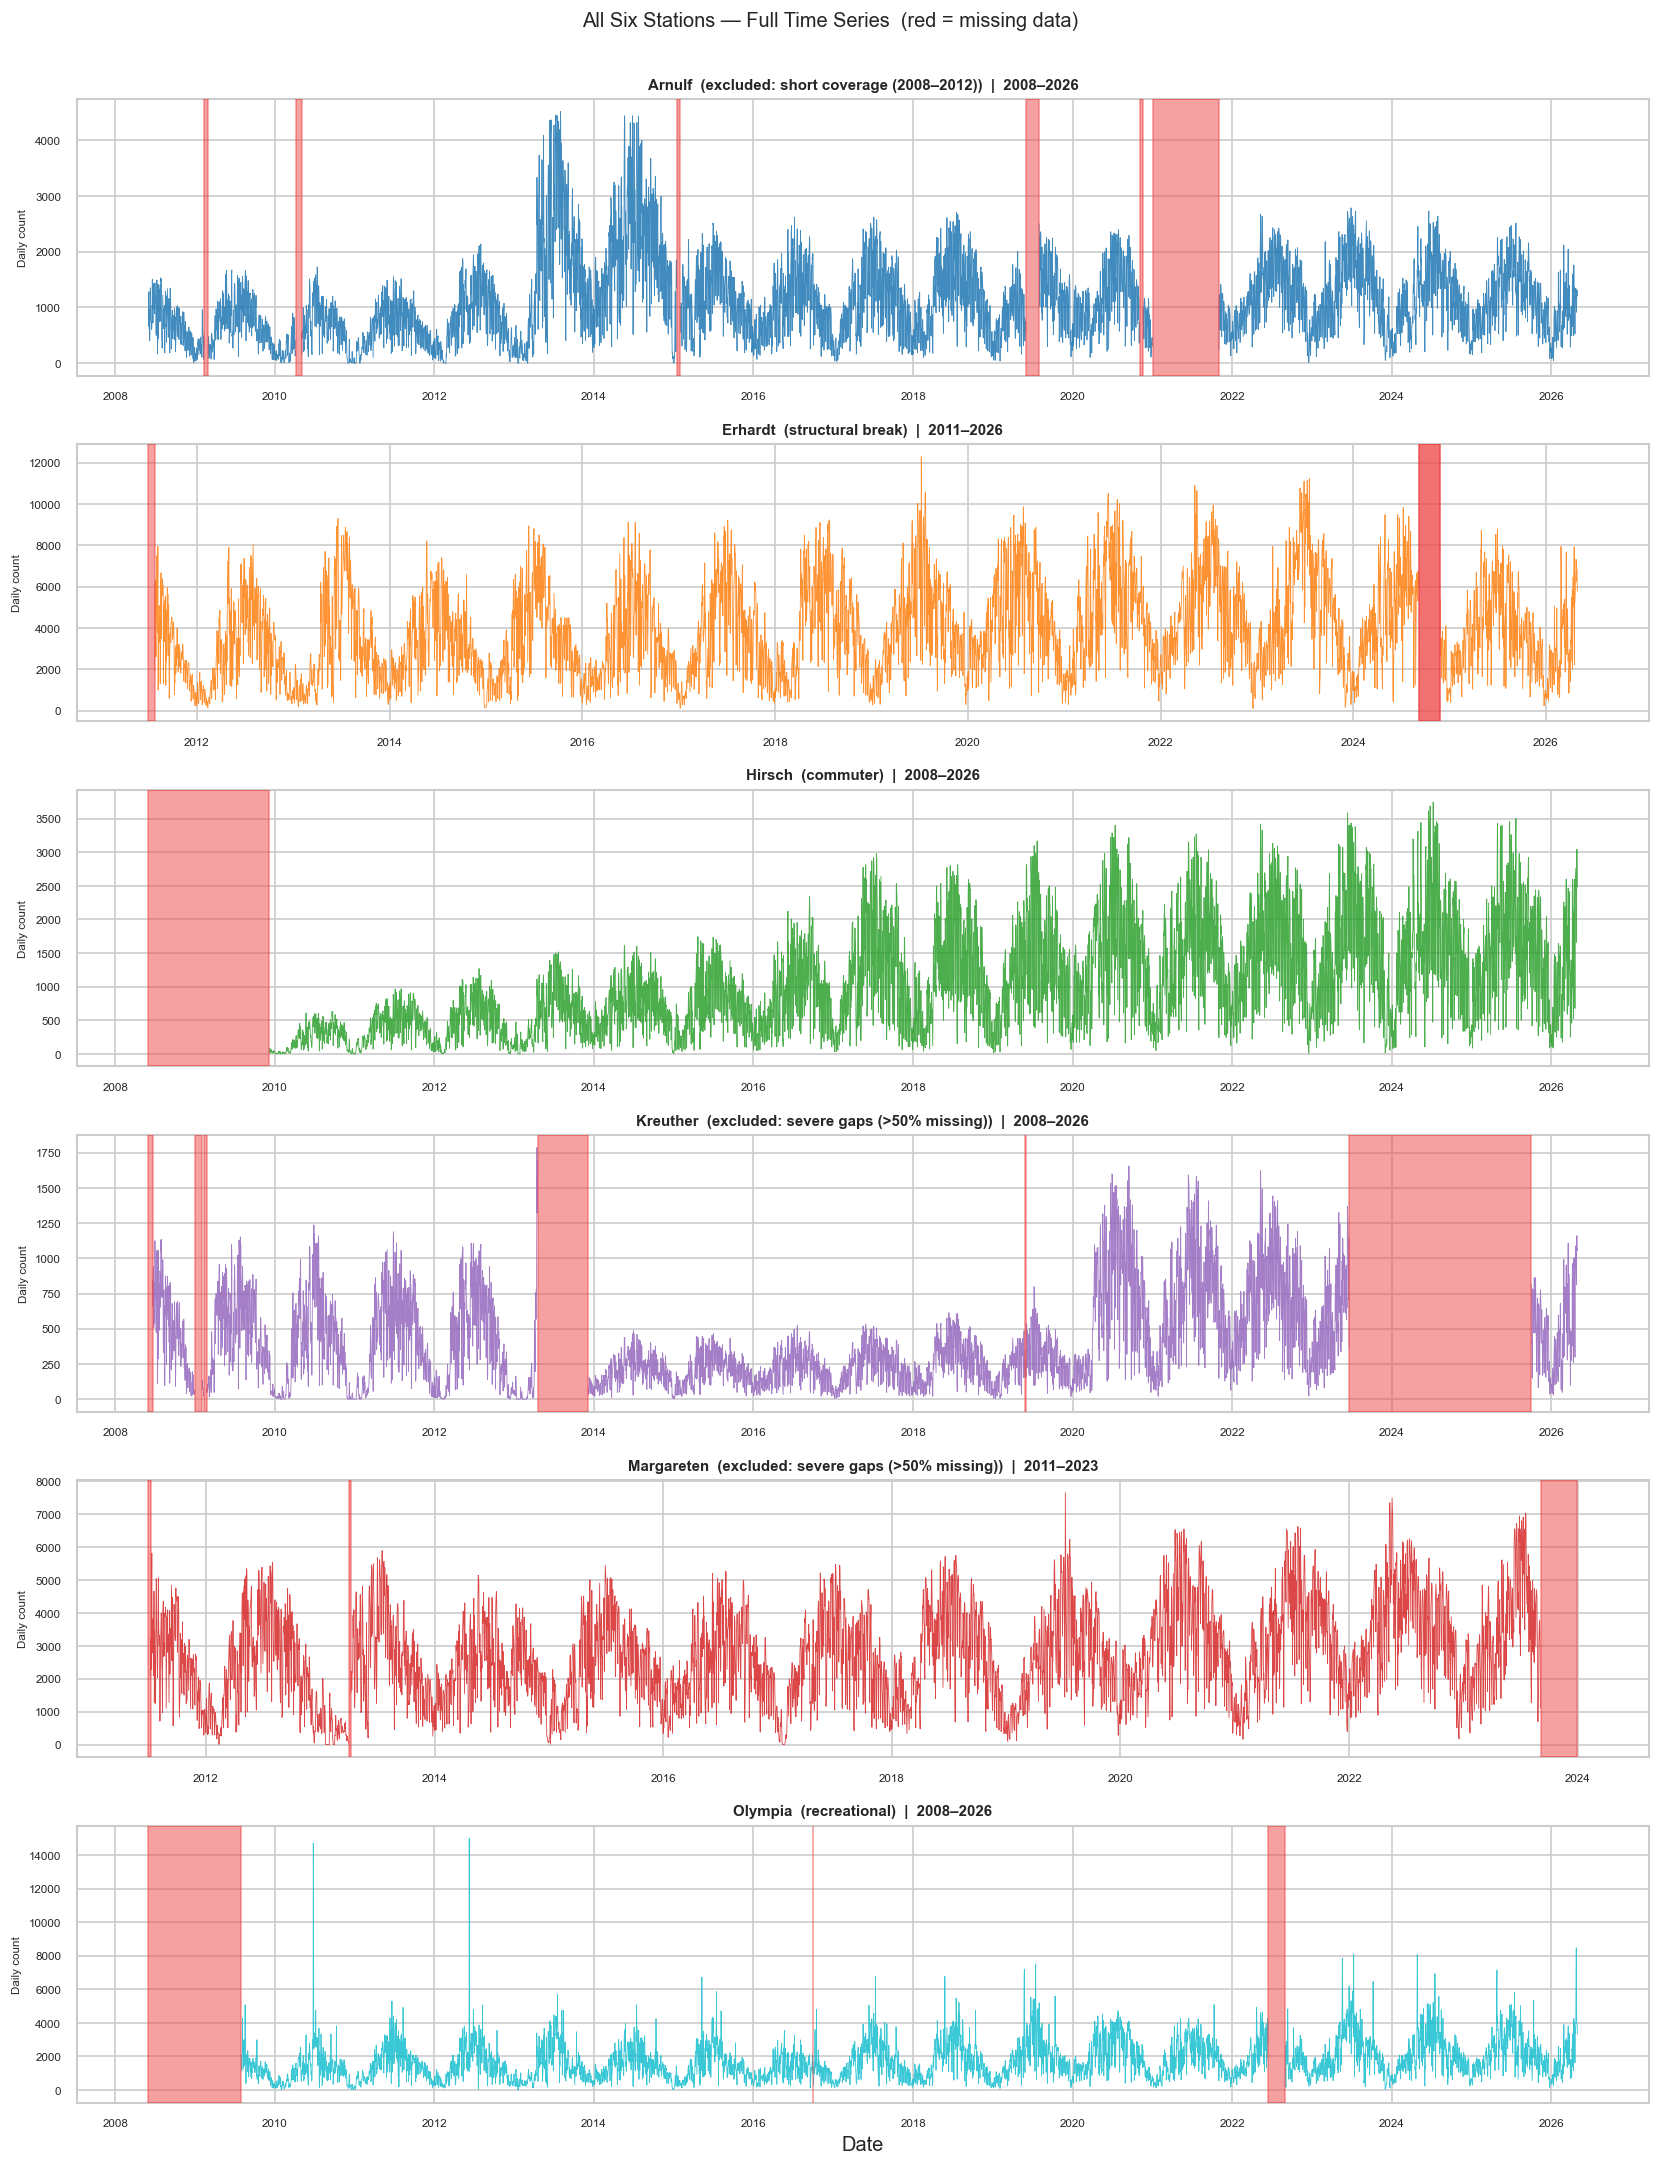

  saved → results/figures/nb02_fig_21_all_stations_timeseries.png


In [25]:
# ── nb02_fig_21 — all stations timeseries ────────────────────────────────────
EXCLUDED_NOTE = {
    'Arnulf'    : 'excluded: short coverage (2008–2012)',
    'Kreuther'  : 'excluded: severe gaps (>50% missing)',
    'Margareten': 'excluded: severe gaps (>50% missing)',
}
STATION_TYPE = {'Hirsch': 'commuter', 'Olympia': 'recreational', 'Erhardt': 'structural break'}

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=False)
for ax, st in zip(axes, STATIONS):   # STATIONS = list(COLORS) — all 6
    sdf  = df[df['station'] == st].set_index('date').sort_index()
    full = sdf.reindex(pd.date_range(sdf.index.min(), sdf.index.max()))
    ax.plot(full.index, full['total'], lw=0.5, color=COLORS[st], alpha=0.85)

    in_gap = False; g0 = None
    for d, v in full['total'].items():
        if pd.isna(v) and not in_gap:
            in_gap = True; g0 = d
        elif not pd.isna(v) and in_gap:
            ax.axvspan(g0, d, color='#ef4444', alpha=0.5, zorder=3); in_gap = False
    if in_gap:
        ax.axvspan(g0, full.index[-1], color='#ef4444', alpha=0.5, zorder=3)
    if st == 'Erhardt':
        ax.axvspan(pd.Timestamp('2024-09-06'), pd.Timestamp('2024-11-26'),
                   color='#ef4444', alpha=0.5, zorder=3)

    yr0, yr1 = full.index[0].year, full.index[-1].year
    note = EXCLUDED_NOTE.get(st, STATION_TYPE.get(st, ''))
    ax.set_title(f'{st}  ({note})  |  {yr0}–{yr1}', fontsize=9)
    ax.set_ylabel('Daily count', fontsize=7); ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Date')
fig.suptitle('All Six Stations — Full Time Series  (red = missing data)',
             fontsize=12, y=1.002)
fig.tight_layout()
savefig('fig_21_all_stations_timeseries')


---
## Thesis figure: Munich weather time series (nb02_fig_22)

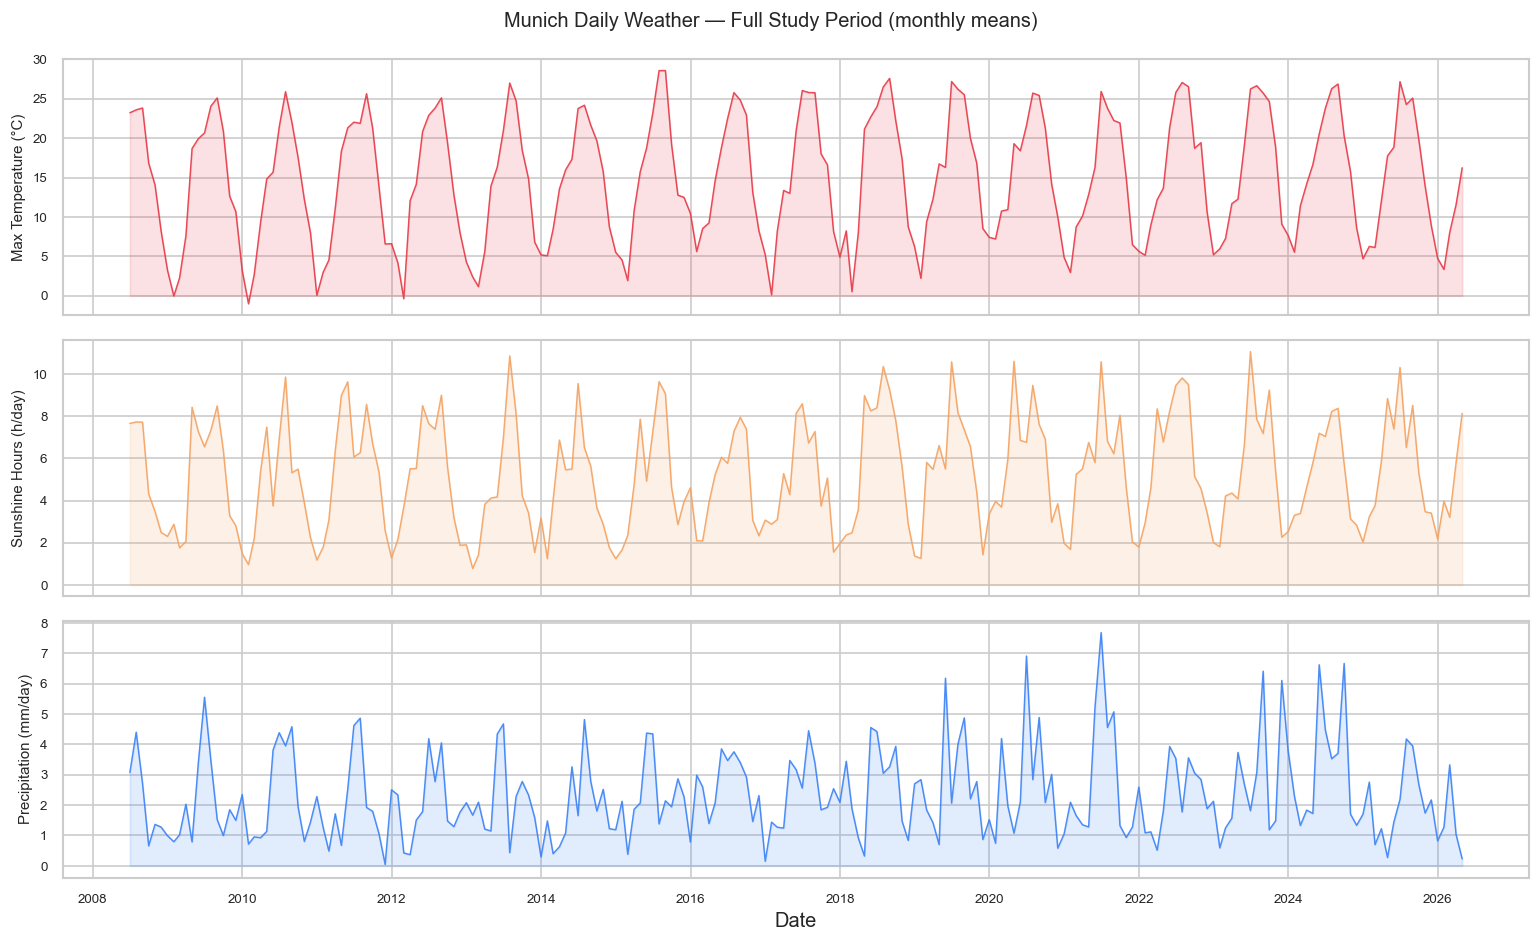

  saved → results/figures/nb02_fig_22_weather_time_series.png


In [26]:
# ── nb02_fig_22 — weather time series (monthly means) ───────────────────────
wx = (df[df['station'] == 'Hirsch']
      [['date', 'max_temp', 'sunshine_hours', 'precipitation']]
      .drop_duplicates('date').set_index('date').sort_index())
wx_m = wx.resample('ME').mean()

panels = [
    ('max_temp',       'Max Temperature (°C)',   '#e63946'),
    ('sunshine_hours', 'Sunshine Hours (h/day)', '#f4a261'),
    ('precipitation',  'Precipitation (mm/day)', '#3b82f6'),
]
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, (col, label, color) in zip(axes, panels):
    ax.plot(wx_m.index, wx_m[col], lw=0.9, color=color, alpha=0.9)
    ax.fill_between(wx_m.index, wx_m[col], alpha=0.15, color=color)
    ax.set_ylabel(label, fontsize=9); ax.tick_params(labelsize=8)
axes[-1].set_xlabel('Date')
fig.suptitle('Munich Daily Weather — Full Study Period (monthly means)', fontsize=12)
fig.tight_layout()
savefig('fig_22_weather_time_series')
